# CARTS empirical experiments with Llama 3 8B

This notebook runs empirical explorations for the CARTS paper using Meta-Llama-3-8B-Instruct Q4_K_M GGUF through `llama-cpp-python`. It tests exact correctness, rank-likelihood behavior, finite key-collision fibers, collision stability, non-commutativity, and robustness to token perturbations.

All computations are framed around token ranks:

- `R_c(x)` is the autoregressive rank trace of token sequence `x` under context `c`.
- `G_c(r)` is the autoregressive generator that emits the token with rank `r_i` at each step under context `c`.
- `E_k(x) = G_k(R_empty(x))` encodes a payload under key context `k`.
- `D_k(y) = G_empty(R_k(y))` decodes a stegotext under the same key.
- `F_k(r) = R_empty(G_k(r))` is the key-induced rank-space map.

The notebook saves figures, CSV tables, raw JSON/JSONL files, and a paper-ready Markdown summary under `paper-empirical-explorations/results/`.

Security language note: these experiments do not prove steganographic security or insecurity. They describe behavior under this model and tokenizer, under finite key sets, under this payload/key sample, and under the stated comparison distribution.


## 1. Imports and paths

This section imports the utility module, creates the result directory tree, prints the runtime environment, and initializes figure/table manifests. The notebook is designed to work whether Jupyter starts in the repository root or inside this notebook directory.


In [1]:
from pathlib import Path
import itertools
import math
import random
import statistics
import sys
import time
from collections import defaultdict

import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display, Markdown, Image
except ImportError:
    display = print
    Markdown = lambda text: text
    Image = None

NOTEBOOK_CWD = Path.cwd()
if (NOTEBOOK_CWD / "carts_empirical_utils.py").exists():
    EXP_DIR = NOTEBOOK_CWD
else:
    EXP_DIR = (NOTEBOOK_CWD / "paper-empirical-explorations").resolve()

if str(EXP_DIR) not in sys.path:
    sys.path.insert(0, str(EXP_DIR))

import carts_empirical_utils as cu

cu.ensure_dirs()
print("Experiment directory:", cu.EXPERIMENT_ROOT)
print("Figures:", cu.FIGURES_DIR)
print("Tables:", cu.TABLES_DIR)
print("Raw:", cu.RAW_DIR)
print("Text:", cu.TEXT_DIR)
print("Cache:", cu.CACHE_DIR)
print("Environment:", cu.environment_info())

FIGURE_MANIFEST = []
TABLE_MANIFEST = []
PAPER_BULLETS = []


def record_figure(filename, experiment, caption_suggestion, paper_claim_supported):
    FIGURE_MANIFEST.append({
        "figure_file": str(cu.FIGURES_DIR / filename),
        "experiment": experiment,
        "caption_suggestion": caption_suggestion,
        "paper_claim_supported": paper_claim_supported,
    })


def record_table(filename, experiment, description, paper_claim_supported):
    TABLE_MANIFEST.append({
        "table_file": str(cu.TABLES_DIR / filename),
        "experiment": experiment,
        "description": description,
        "paper_claim_supported": paper_claim_supported,
    })


def show_rows(rows, n=10):
    rows = list(rows)
    if pd is not None:
        display(pd.DataFrame(rows).head(n))
    else:
        display(rows[:n])


Experiment directory: /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations
Figures: /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/figures
Tables: /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/tables
Raw: /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/raw
Text: /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/text
Cache: /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/cache
Environment: {'python': '3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]', 'platform': 'Linux-6.17.0-22-generic-x86_64-with-glibc2.39', 'numpy': '2.3.5', 'sklearn_available': True, 'llama_cpp': '0.3.16', 'matplotlib': '3.10.7'}


## 2. Configuration

The defaults are deliberately CPU-friendly. Increase the sample sizes only after the smoke test and implementation correctness test pass. `quick_mode=False` expands several sample sizes but still keeps the code deterministic.


In [2]:
CONFIG = {
    "model_key": "llama3_8b_q4_k_m",
    "secret_prefix": "",
    "random_seed": 123,
    "quick_mode": True,
    "allow_failures": False,

    "n_ctx": 4096,
    "n_gpu_layers": 0,
    "n_threads": None,

    "num_payloads": 8,
    "num_keys": 10,
    "num_payload_key_pairs": 8,

    "num_collision_payloads": 6,
    "num_stability_payloads": 8,
    "num_commutativity_pairs": 12,
    "num_commutativity_payloads": 6,
    "num_robustness_cases": 6,

    "tail_thresholds": [10, 100, 1000],
    "use_sklearn_detector": True,
    "use_embeddings": False,
}

if not CONFIG["quick_mode"]:
    CONFIG.update({
        "num_payload_key_pairs": 24,
        "num_collision_payloads": 12,
        "num_stability_payloads": 16,
        "num_commutativity_pairs": 36,
        "num_commutativity_payloads": 12,
        "num_robustness_cases": 16,
    })

random.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

cu.reset_summary("CARTS Empirical Summary")
cu.append_summary(
    "Experimental configuration",
    "```json\n" + __import__("json").dumps(CONFIG, indent=2, sort_keys=True) + "\n```\n\n"
    + "Tokenization convention:\n\n"
    + "- " + cu.TOKENIZATION_CONVENTION["prefix_context"] + "\n"
    + "- " + cu.TOKENIZATION_CONVENTION["payload_text"] + "\n"
    + "- " + cu.TOKENIZATION_CONVENTION["rank_order"] + "\n",
)
print(CONFIG)


{'model_key': 'llama3_8b_q4_k_m', 'secret_prefix': '', 'random_seed': 123, 'quick_mode': True, 'allow_failures': False, 'n_ctx': 4096, 'n_gpu_layers': 0, 'n_threads': None, 'num_payloads': 8, 'num_keys': 10, 'num_payload_key_pairs': 8, 'num_collision_payloads': 6, 'num_stability_payloads': 8, 'num_commutativity_pairs': 12, 'num_commutativity_payloads': 6, 'num_robustness_cases': 6, 'tail_thresholds': [10, 100, 1000], 'use_sklearn_detector': True, 'use_embeddings': False}


## 3. Load Llama 3 8B model

The main experiments require `models/llama3_8b/Meta-Llama-3-8B-Instruct-Q4_K_M.gguf`. The loader raises a clear error if the file is missing; it does not silently fall back to Phi-3.

The important implementation settings are `logits_all=True`, full-vocabulary ranking, CPU-safe `n_gpu_layers=0`, and deterministic rank tie-breaking by token id.


In [3]:
model_info = cu.MODEL_REGISTRY[CONFIG["model_key"]]
model_path = cu.REPO_ROOT / model_info["path"]
print("Model key:", CONFIG["model_key"])
print("Model description:", model_info["description"])
print("Expected model path:", model_path)

llm = cu.load_language_model(
    model_key=CONFIG["model_key"],
    n_threads=CONFIG["n_threads"],
    n_gpu_layers=CONFIG["n_gpu_layers"],
    n_ctx=CONFIG["n_ctx"],
    logits_all=True,
)

VOCAB_SIZE = cu.get_vocab_size(llm)
BOS_ID = cu.get_bos_id(llm)
EOS_ID = cu.get_eos_id(llm)
print("n_ctx:", CONFIG["n_ctx"])
print("logits_all:", True)
print("vocabulary size:", VOCAB_SIZE)
print("BOS token id:", BOS_ID)
print("EOS token id:", EOS_ID)
print("Tokenization convention:")
for key, value in cu.TOKENIZATION_CONVENTION.items():
    print(f"  {key}: {value}")

cu.save_manifest(CONFIG, cu.environment_info())


Model key: llama3_8b_q4_k_m
Model description: Meta-Llama-3-8B-Instruct Q4_K_M GGUF
Expected model path: /home/meow/Documents/repos/LlmStenoExplore/models/llama3_8b/Meta-Llama-3-8B-Instruct-Q4_K_M.gguf


llama_context: n_ctx_per_seq (4096) < n_ctx_train (8192) -- the full capacity of the model will not be utilized


n_ctx: 4096
logits_all: True
vocabulary size: 128256
BOS token id: 128000
EOS token id: 128001
Tokenization convention:
  prefix_context: Non-empty prefixes are tokenized with add_bos=True and the first BOS token is dropped. Empty prefixes use the model BOS token as the minimal autoregressive context.
  payload_text: Payload and stegotext display strings are tokenized as model.tokenize((' ' + text).encode('utf-8'), add_bos=True)[1:].
  rank_order: Ranks are 1-indexed. Tokens are sorted by decreasing logit with ties broken by increasing token id.


PosixPath('/home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/raw/run_config.json')

## 4. Payload and key sets

The default payloads and keys are small and diverse so the full notebook can run on CPU. Payload lengths are recorded in token ids. Experiments that require same-length rank vectors explicitly choose same-length vectors or record when a payload has been truncated to the required length.


In [4]:
PAYLOADS = [
    {"category": "mundane natural language", "text": "Switzerland is expensive."},
    {"category": "factual sentence", "text": "The meeting starts after lunch."},
    {"category": "policy-like sentence", "text": "The current policy has failed."},
    {"category": "short sentence", "text": "A quiet river crossed the valley."},
    {"category": "longer sentence", "text": "The lab notebook was hidden in the cabinet."},
    {"category": "mundane natural language", "text": "A small bird landed near the window."},
    {"category": "factual sentence", "text": "The archive contains several old records."},
    {"category": "repeated simple payload", "text": "The device stopped working after midnight."},
]

KEYS = [
    {"category": "cooking", "text": "Write about baking bread."},
    {"category": "travel", "text": "Describe a quiet mountain village."},
    {"category": "animals", "text": "Talk about animals in a forest."},
    {"category": "sports", "text": "Explain a baseball practice."},
    {"category": "history", "text": "Describe ancient Roman roads."},
    {"category": "neutral", "text": "Write a neutral product description."},
    {"category": "near duplicate", "text": "The quick brown fox jumps"},
    {"category": "near duplicate typo", "text": "The quick brow fox jumps"},
    {"category": "short cooking", "text": "Flour is cheap"},
    {"category": "object scene", "text": "A wooden barrel sits in a cellar"},
]

PAYLOADS = PAYLOADS[:CONFIG["num_payloads"]]
KEYS = KEYS[:CONFIG["num_keys"]]

payload_records = []
for idx, payload in enumerate(PAYLOADS):
    token_ids = cu.text_to_payload_ids(payload["text"], llm)
    payload_records.append({
        "payload_id": idx,
        "category": payload["category"],
        "text": payload["text"],
        "token_ids": token_ids,
        "token_length": len(token_ids),
    })

key_records = []
for idx, key in enumerate(KEYS):
    context_ids = cu._make_prefix_ids(key["text"], llm)
    key_records.append({
        "key_id": idx,
        "category": key["category"],
        "text": key["text"],
        "context_ids": context_ids,
        "context_token_length": len(context_ids),
    })

cu.write_csv(cu.TABLES_DIR / "payloads.csv", payload_records)
cu.write_csv(cu.TABLES_DIR / "keys.csv", key_records)
record_table("payloads.csv", "Section 4", "Default payload set and token lengths.", "Defines tested payload distribution.")
record_table("keys.csv", "Section 4", "Default key set and context token lengths.", "Defines tested key distribution.")

show_rows([{k: v for k, v in row.items() if k != "token_ids"} for row in payload_records])
show_rows([{k: v for k, v in row.items() if k != "context_ids"} for row in key_records])


[{'payload_id': 0,
  'category': 'mundane natural language',
  'text': 'Switzerland is expensive.',
  'token_length': 4},
 {'payload_id': 1,
  'category': 'factual sentence',
  'text': 'The meeting starts after lunch.',
  'token_length': 6},
 {'payload_id': 2,
  'category': 'policy-like sentence',
  'text': 'The current policy has failed.',
  'token_length': 6},
 {'payload_id': 3,
  'category': 'short sentence',
  'text': 'A quiet river crossed the valley.',
  'token_length': 7},
 {'payload_id': 4,
  'category': 'longer sentence',
  'text': 'The lab notebook was hidden in the cabinet.',
  'token_length': 9},
 {'payload_id': 5,
  'category': 'mundane natural language',
  'text': 'A small bird landed near the window.',
  'token_length': 8},
 {'payload_id': 6,
  'category': 'factual sentence',
  'text': 'The archive contains several old records.',
  'token_length': 7},
 {'payload_id': 7,
  'category': 'repeated simple payload',
  'text': 'The device stopped working after midnight.',
  'to

[{'key_id': 0,
  'category': 'cooking',
  'text': 'Write about baking bread.',
  'context_token_length': 5},
 {'key_id': 1,
  'category': 'travel',
  'text': 'Describe a quiet mountain village.',
  'context_token_length': 6},
 {'key_id': 2,
  'category': 'animals',
  'text': 'Talk about animals in a forest.',
  'context_token_length': 7},
 {'key_id': 3,
  'category': 'sports',
  'text': 'Explain a baseball practice.',
  'context_token_length': 6},
 {'key_id': 4,
  'category': 'history',
  'text': 'Describe ancient Roman roads.',
  'context_token_length': 5},
 {'key_id': 5,
  'category': 'neutral',
  'text': 'Write a neutral product description.',
  'context_token_length': 6},
 {'key_id': 6,
  'category': 'near duplicate',
  'text': 'The quick brown fox jumps',
  'context_token_length': 5},
 {'key_id': 7,
  'category': 'near duplicate typo',
  'text': 'The quick brow fox jumps',
  'context_token_length': 5},
 {'key_id': 8,
  'category': 'short cooking',
  'text': 'Flour is cheap',
  'co

## 5. Smoke test

This verifies one concrete `E_k`/`D_k` round trip before running the empirical section. The exact pass condition is token-id equality. String equality is printed only as display metadata. If this fails and `allow_failures=False`, the notebook stops because later experiments would not be trustworthy.


In [5]:
smoke_payload = payload_records[0]
smoke_key = key_records[0]
encoded = cu.E_key_token_ids(
    llm,
    smoke_payload["token_ids"],
    smoke_key["text"],
    secret_prefix=CONFIG["secret_prefix"],
)
decoded = cu.D_key_token_ids(
    llm,
    encoded["stegotext_ids"],
    smoke_key["text"],
    secret_prefix=CONFIG["secret_prefix"],
)
exact = cu.exact_match(decoded["decoded_ids"], smoke_payload["token_ids"])
print("Payload:", smoke_payload["text"])
print("Key:", smoke_key["text"])
print("Payload token IDs:", smoke_payload["token_ids"])
print("Ranks:", encoded["ranks"])
print("Stegotext:", encoded["stegotext_text"])
print("Decoded text:", decoded["decoded_text"])
print("Exact token match:", exact)
print("Display string equality:", decoded["decoded_text"].strip() == smoke_payload["text"].strip())

smoke_row = {
    "payload": smoke_payload["text"],
    "key": smoke_key["text"],
    "payload_token_ids": smoke_payload["token_ids"],
    "ranks": encoded["ranks"],
    "stegotext_ids": encoded["stegotext_ids"],
    "decoded_ids": decoded["decoded_ids"],
    "exact_token_match": exact,
}
cu.write_json(cu.RAW_DIR / "smoke_test.json", smoke_row)

if not exact:
    warning = "Smoke test failed: exact token-id round trip did not recover the payload."
    print("WARNING:", warning)
    if not CONFIG["allow_failures"]:
        raise RuntimeError(warning + " Set CONFIG['allow_failures']=True only for debugging.")


Payload: Switzerland is expensive.
Key: Write about baking bread.
Payload token IDs: [30221, 374, 11646, 13]
Ranks: [74364, 3, 435, 2]
Stegotext:  Porno
Anybody
Decoded text:  Switzerland is expensive.
Exact token match: True
Display string equality: True


# Experiment 1: Implementation correctness

**Theory object tested.** This experiment tests the mutual-inverse identities `D_k(E_k(x)) = x` and, when starting from an encoded stegotext, `E_k(D_k(y)) = y`.

**Data.** A deterministic sample of payload-key pairs from Section 4.

**Metrics.** Exact token-id equality, display string equality, first mismatch position for failures.

**Plots and outputs.** A recovery-rate bar chart and a correctness table. A mismatch-position histogram is produced only if failures occur.

**Claim supported.** The implementation realizes exact CARTS round trips on the tested samples under this model and tokenizer. Failures would indicate implementation mismatch, not a failure of the mathematical theorem.


[{'case_id': 0,
  'payload_id': 3,
  'key_id': 2,
  'payload_text': 'A quiet river crossed the valley.',
  'key_text': 'Talk about animals in a forest.',
  'payload_token_length': 7,
  'decode_exact_token_match': True,
  'reverse_exact_token_match': True,
  'display_string_match': True,
  'first_mismatch_position': None,
  'stegotext_text': 'Pressed backwards/extension of fingers to',
  'decoded_text': ' A quiet river crossed the valley.',
  'ranks': [99353, 662, 72, 684, 1, 8, 4]},
 {'case_id': 1,
  'payload_id': 7,
  'key_id': 2,
  'payload_text': 'The device stopped working after midnight.',
  'key_text': 'Talk about animals in a forest.',
  'payload_token_length': 7,
  'decode_exact_token_match': True,
  'reverse_exact_token_match': True,
  'display_string_match': True,
  'first_mismatch_position': None,
  'stegotext_text': '"/>.</gtk_item>\n``”\n\nThis',
  'decoded_text': ' The device stopped working after midnight.',
  'ranks': [89803, 729, 533, 1, 1, 354, 1]},
 {'case_id': 2,
  

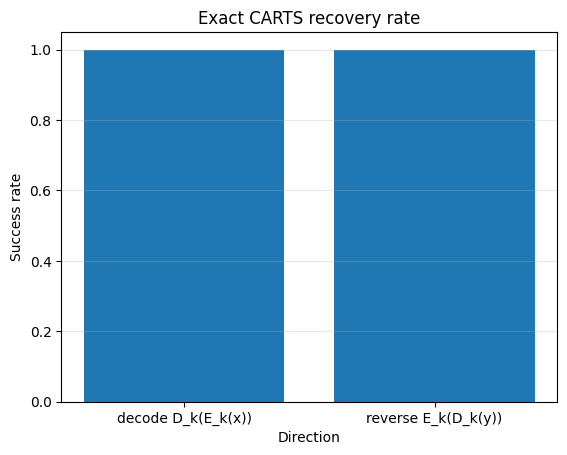

In [6]:
def sampled_payload_key_pairs(limit):
    pairs = list(itertools.product(payload_records, key_records))
    rng = random.Random(CONFIG["random_seed"])
    rng.shuffle(pairs)
    return pairs[:limit]

exp1_rows = []
for case_id, (payload, key) in enumerate(sampled_payload_key_pairs(CONFIG["num_payload_key_pairs"])):
    encoded = cu.E_key_token_ids(llm, payload["token_ids"], key["text"], CONFIG["secret_prefix"])
    decoded = cu.D_key_token_ids(llm, encoded["stegotext_ids"], key["text"], CONFIG["secret_prefix"])
    decode_exact = cu.exact_match(decoded["decoded_ids"], payload["token_ids"])

    reencoded = cu.E_key_token_ids(llm, decoded["decoded_ids"], key["text"], CONFIG["secret_prefix"])
    reverse_exact = cu.exact_match(reencoded["stegotext_ids"], encoded["stegotext_ids"])

    exp1_rows.append({
        "case_id": case_id,
        "payload_id": payload["payload_id"],
        "key_id": key["key_id"],
        "payload_text": payload["text"],
        "key_text": key["text"],
        "payload_token_length": len(payload["token_ids"]),
        "decode_exact_token_match": decode_exact,
        "reverse_exact_token_match": reverse_exact,
        "display_string_match": decoded["decoded_text"].strip() == payload["text"].strip(),
        "first_mismatch_position": cu.first_mismatch_position(decoded["decoded_ids"], payload["token_ids"]),
        "stegotext_text": encoded["stegotext_text"],
        "decoded_text": decoded["decoded_text"],
        "ranks": encoded["ranks"],
    })

cu.write_csv(cu.TABLES_DIR / "experiment1_correctness.csv", exp1_rows)
cu.write_json(cu.RAW_DIR / "experiment1_correctness.json", exp1_rows)
record_table("experiment1_correctness.csv", "Experiment 1", "Round-trip status for each payload-key pair.", "Exact invertibility implementation check.")

num_cases = len(exp1_rows)
decode_success = sum(row["decode_exact_token_match"] for row in exp1_rows)
reverse_success = sum(row["reverse_exact_token_match"] for row in exp1_rows)
decode_rate = decode_success / max(num_cases, 1)
reverse_rate = reverse_success / max(num_cases, 1)

cu.bar_plot(
    ["decode D_k(E_k(x))", "reverse E_k(D_k(y))"],
    [decode_rate, reverse_rate],
    "exp1_correctness_bar.png",
    "Exact CARTS recovery rate",
    "Direction",
    "Success rate",
)
record_figure("exp1_correctness_bar.png", "Experiment 1", "Exact token-id recovery rates for decode and reverse directions.", "Exact invertibility on tested samples.")

failure_positions = [row["first_mismatch_position"] for row in exp1_rows if row["first_mismatch_position"] is not None]
if failure_positions:
    cu.histogram(
        failure_positions,
        "exp1_mismatch_positions.png",
        "First mismatch positions for failed round trips",
        "First mismatch token position",
    )
    record_figure("exp1_mismatch_positions.png", "Experiment 1", "First mismatch positions for failed CARTS round trips.", "Implementation debugging only.")

summary = (
    f"Exact recovery succeeded in {decode_success}/{num_cases} payload-key pairs under Llama 3 8B "
    f"with the specified deterministic settings. Reverse-direction recovery succeeded in "
    f"{reverse_success}/{num_cases} cases."
)
if failure_positions:
    summary += " Failures occurred and indicate implementation mismatch, not a failure of the theorem."
PAPER_BULLETS.append(summary)
cu.append_summary("Implementation correctness result", summary)
show_rows(exp1_rows)

if decode_success != num_cases and not CONFIG["allow_failures"]:
    raise RuntimeError("Experiment 1 failed exact token recovery. Stop before interpreting later experiments.")


# Experiment 2: Rank-likelihood, rank-trace statistics, and simple detection

**Theory object tested.** This experiment studies rank pressure induced by `E_k(x) = G_k(R_empty(x))`. CARTS stegotexts inherit the payload rank trace under the key context, while ordinary greedy comparison text under the same key has rank 1 at each generated position.

**Data.** The same deterministic payload-key sample as Experiment 1.

**Metrics.** Normalized NLL under the key context, mean log-rank, max log-rank, tail-rank fractions, and sequence length.

**Comparison distribution.** `Q_k` is ordinary greedy generation under the same key context for exactly `n` tokens. This is a deliberately simple comparison distribution, not a universal natural-text baseline.

**Plots and outputs.** NLL boxplot, mean-log-rank CDF, tail-rank versus NLL scatter, position-wise mean-log-rank heatmap, and an optional ROC curve for a simple rank-feature detector.

**Claim supported.** Empirical rank and likelihood behavior under this model, tokenizer, payload sample, key sample, and `Q_k`. This is not a proof of steganographic distinguishability in general.


[{'case_id': 0,
  'class': 'CARTS',
  'payload_id': 3,
  'key_id': 2,
  'payload_text': 'A quiet river crossed the valley.',
  'key_text': 'Talk about animals in a forest.',
  'comparison_distribution': 'CARTS E_k(x)',
  'token_length': 7,
  'normalized_nll': 7.697680141695089,
  'mean_log_rank': 4.6102942770250275,
  'max_log_rank': 11.506434443799858,
  'generated_text': 'Pressed backwards/extension of fingers to',
  'ranks': [99353, 662, 72, 684, 1, 8, 4],
  'tail_rank_fraction_gt_10': 0.5714285714285714,
  'tail_rank_fraction_gt_100': 0.42857142857142855,
  'tail_rank_fraction_gt_1000': 0.14285714285714285},
 {'case_id': 0,
  'class': 'ordinary',
  'payload_id': 3,
  'key_id': 2,
  'payload_text': 'A quiet river crossed the valley.',
  'key_text': 'Talk about animals in a forest.',
  'comparison_distribution': 'ordinary greedy Q_k',
  'token_length': 7,
  'normalized_nll': 0.9962059602768333,
  'mean_log_rank': 0.0,
  'max_log_rank': 0.0,
  'generated_text': ' What do you see? What

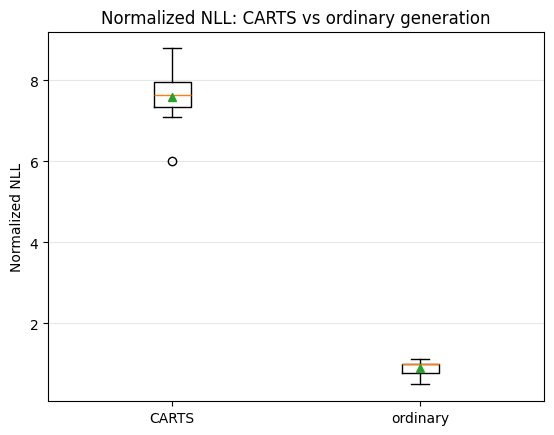

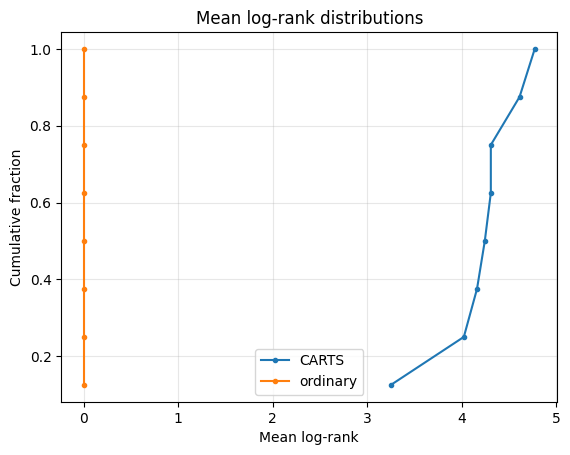

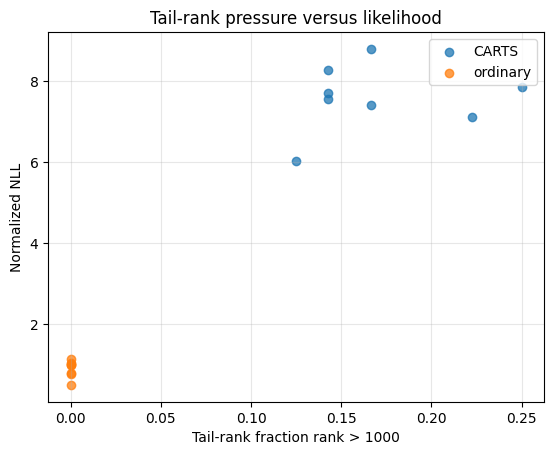

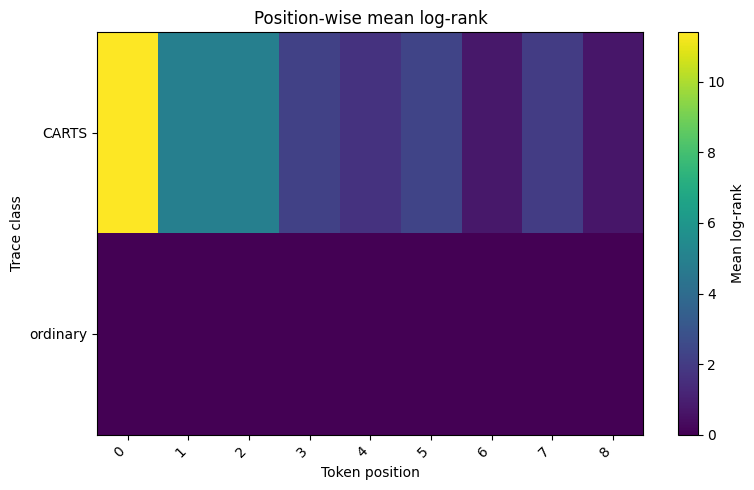

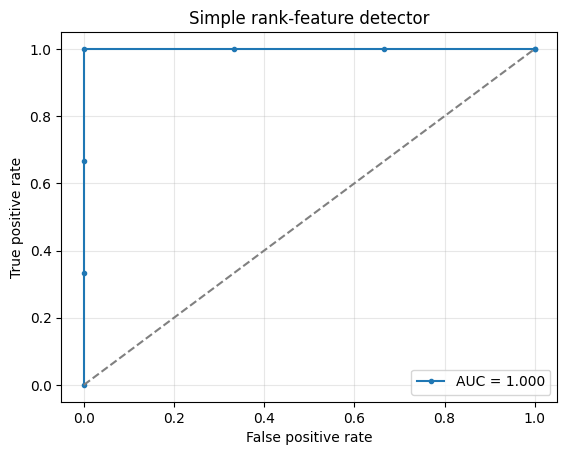

In [7]:
def rank_features(prefix, ranks, nll, token_length):
    row = {
        f"{prefix}_normalized_nll": nll,
        f"{prefix}_mean_log_rank": cu.mean_log_rank(ranks),
        f"{prefix}_max_log_rank": cu.max_log_rank(ranks),
        f"{prefix}_token_length": token_length,
    }
    for B in CONFIG["tail_thresholds"]:
        row[f"{prefix}_tail_rank_fraction_gt_{B}"] = cu.tail_rank_fraction(ranks, B)
    return row

exp2_rows = []
positionwise = {"CARTS": [], "ordinary": []}
detector_features = []
detector_labels = []
feature_names = ["normalized_nll", "mean_log_rank", "max_log_rank", "token_length"] + [f"tail_gt_{B}" for B in CONFIG["tail_thresholds"]]

for case_id, (payload, key) in enumerate(sampled_payload_key_pairs(CONFIG["num_payload_key_pairs"])):
    n = len(payload["token_ids"])
    encoded = cu.E_key_token_ids(llm, payload["token_ids"], key["text"], CONFIG["secret_prefix"])
    carts_ranks = encoded["ranks"]
    carts_nll = encoded["stegotext_generation"]["normalized_nll"]

    ordinary = cu.ordinary_greedy_generation(llm, key["text"], n, secret_prefix=CONFIG["secret_prefix"])
    ordinary_trace = cu.rank_trace_from_token_ids(
        llm,
        cu._make_prefix_ids(key["text"], llm),
        ordinary["generated_ids"],
    )
    ordinary_ranks = ordinary_trace["ranks"]
    ordinary_nll = ordinary_trace["normalized_nll"]

    if len(ordinary["generated_ids"]) != n:
        raise RuntimeError("Ordinary comparison generation did not produce the requested length.")

    for label, ranks, nll, text in [
        ("CARTS", carts_ranks, carts_nll, encoded["stegotext_text"]),
        ("ordinary", ordinary_ranks, ordinary_nll, ordinary["generated_text"]),
    ]:
        row = {
            "case_id": case_id,
            "class": label,
            "payload_id": payload["payload_id"],
            "key_id": key["key_id"],
            "payload_text": payload["text"],
            "key_text": key["text"],
            "comparison_distribution": "ordinary greedy Q_k" if label == "ordinary" else "CARTS E_k(x)",
            "token_length": n,
            "normalized_nll": nll,
            "mean_log_rank": cu.mean_log_rank(ranks),
            "max_log_rank": cu.max_log_rank(ranks),
            "generated_text": text,
            "ranks": ranks,
        }
        for B in CONFIG["tail_thresholds"]:
            row[f"tail_rank_fraction_gt_{B}"] = cu.tail_rank_fraction(ranks, B)
        exp2_rows.append(row)
        detector_features.append([row["normalized_nll"], row["mean_log_rank"], row["max_log_rank"], row["token_length"]] + [row[f"tail_rank_fraction_gt_{B}"] for B in CONFIG["tail_thresholds"]])
        detector_labels.append(1 if label == "CARTS" else 0)
        positionwise[label].append([math.log(max(int(rank), 1)) for rank in ranks])

cu.write_csv(cu.TABLES_DIR / "experiment2_rank_likelihood_detection.csv", exp2_rows)
cu.write_json(cu.RAW_DIR / "experiment2_rank_likelihood_detection.json", exp2_rows)
record_table("experiment2_rank_likelihood_detection.csv", "Experiment 2", "Rank-likelihood and detector features for CARTS and ordinary greedy comparison text.", "Rank pressure and simple detectability under Q_k.")

nll_by_class = defaultdict(list)
mean_log_by_class = defaultdict(list)
for row in exp2_rows:
    nll_by_class[row["class"]].append(row["normalized_nll"])
    mean_log_by_class[row["class"]].append(row["mean_log_rank"])

cu.boxplot(nll_by_class, "exp2_nll_boxplot.png", "Normalized NLL: CARTS vs ordinary generation", "Normalized NLL")
record_figure("exp2_nll_boxplot.png", "Experiment 2", "Normalized NLL under the key context for CARTS and ordinary greedy comparison text.", "Rank-likelihood behavior under Q_k.")

cu.empirical_cdf(mean_log_by_class, "exp2_mean_log_rank_cdf.png", "Mean log-rank distributions", "Mean log-rank")
record_figure("exp2_mean_log_rank_cdf.png", "Experiment 2", "Empirical CDF of mean log-rank for CARTS and ordinary comparison traces.", "Rank-trace distribution shift under Q_k.")

primary_B = CONFIG["tail_thresholds"][-1]
cu.scatter_plot(
    [row[f"tail_rank_fraction_gt_{primary_B}"] for row in exp2_rows],
    [row["normalized_nll"] for row in exp2_rows],
    "exp2_tail_rank_vs_nll.png",
    "Tail-rank pressure versus likelihood",
    f"Tail-rank fraction rank > {primary_B}",
    "Normalized NLL",
    labels=[row["class"] for row in exp2_rows],
)
record_figure("exp2_tail_rank_vs_nll.png", "Experiment 2", "Tail-rank fraction versus normalized NLL for CARTS and ordinary traces.", "Rank pressure and likelihood relationship.")

max_len = max(len(seq) for seqs in positionwise.values() for seq in seqs)
heat_rows = []
for label in ["CARTS", "ordinary"]:
    arr = np.full((len(positionwise[label]), max_len), np.nan)
    for i, seq in enumerate(positionwise[label]):
        arr[i, :len(seq)] = seq
    heat_rows.append(np.nanmean(arr, axis=0).tolist())
cu.heatmap(
    heat_rows,
    "exp2_positionwise_mean_log_rank_heatmap.png",
    "Position-wise mean log-rank",
    "Token position",
    "Trace class",
    xticklabels=[str(i) for i in range(max_len)],
    yticklabels=["CARTS", "ordinary"],
    colorbar_label="Mean log-rank",
)
record_figure("exp2_positionwise_mean_log_rank_heatmap.png", "Experiment 2", "Position-wise mean log-rank for CARTS and ordinary comparison traces.", "Position-wise rank pressure.")

if CONFIG["use_sklearn_detector"]:
    detector_result = cu.train_simple_logistic_regression(detector_features, detector_labels, CONFIG["random_seed"])
    if not detector_result["available"]:
        detector_scores = [row["normalized_nll"] for row in exp2_rows]
        detector_auc = cu.roc_auc_score(detector_labels, detector_scores)
        detector_result.update({"auc": detector_auc, "scores": detector_scores, "labels": detector_labels, "note": detector_result["note"] + " Fallback AUC uses normalized NLL only."})
    cu.write_json(cu.RAW_DIR / "experiment2_detector.json", detector_result)
    cu.roc_curve_plot(detector_result["labels"], detector_result["scores"], "exp2_detector_roc.png", "Simple rank-feature detector")
    record_figure("exp2_detector_roc.png", "Experiment 2", "ROC curve for a simple detector trained on rank and likelihood features.", "Simple detectability under this comparison distribution.")
else:
    detector_result = {"available": False, "auc": float("nan"), "note": "Detector disabled by configuration."}

carts_mean_nll = statistics.mean(nll_by_class["CARTS"])
ordinary_mean_nll = statistics.mean(nll_by_class["ordinary"])
carts_mean_log = statistics.mean(mean_log_by_class["CARTS"])
ordinary_mean_log = statistics.mean(mean_log_by_class["ordinary"])
summary = (
    f"CARTS stegotexts had mean normalized NLL {carts_mean_nll:.4f} compared with "
    f"{ordinary_mean_nll:.4f} for ordinary greedy generation. The mean log-rank distribution "
    f"shift was {carts_mean_log - ordinary_mean_log:.4f}. A simple detector achieved AUC "
    f"{detector_result.get('auc', float('nan')):.4f} under this comparison distribution. "
    "This is not a proof of steganographic distinguishability in general; it is only for this model, payload distribution, key distribution, and Q_k."
)
PAPER_BULLETS.append(summary)
cu.append_summary("Rank-likelihood and detection result", summary + "\n\nDetector note: " + str(detector_result.get("note", "")))
show_rows(exp2_rows)


# Experiment 3: Key-collision fiber census and finite key search

**Theory object tested.** This experiment studies finite key-collision fibers for the key-induced map `F_k(r) = R_empty(G_k(r))`.

**Data.** A finite admissible key set `K_adm` containing the default keys, near duplicates, typo variants, template-generated keys, and optionally `data/key_prompts.txt` if present.

**Metrics.** Candidate fiber size `mu = |{k in K_adm : F_k(r) = w}|`, true-key containment, collision count, and finite search cost in number of `F` evaluations.

**Plots and outputs.** Fiber-size histogram, unique-versus-colliding bar chart, finite search cost curve, largest-fibers table.

**Claim supported.** Finite-key collision behavior under this `K_adm`. These results do not characterize the infinite prompt space.


|K_adm| = 31


[{'case_id': 0,
  'payload_id': 0,
  'payload_text': 'Switzerland is expensive.',
  'rank_length': 4,
  'true_key': 'Write about baking bread.',
  'fiber_size': 1,
  'candidate_keys': ['Write about baking bread.'],
  'true_key_in_candidates': True,
  'collisions_verified_without_cache': True,
  'keyset_size': 31,
  'f_evaluations': 31,
  'search_elapsed_seconds': 98.79548505599996,
  'target_w': [19671, 1, 1047, 1]},
 {'case_id': 1,
  'payload_id': 1,
  'payload_text': 'The meeting starts after lunch.',
  'rank_length': 6,
  'true_key': 'Describe a quiet mountain village.',
  'fiber_size': 1,
  'candidate_keys': ['Describe a quiet mountain village.'],
  'true_key_in_candidates': True,
  'collisions_verified_without_cache': True,
  'keyset_size': 31,
  'f_evaluations': 31,
  'search_elapsed_seconds': 135.51734071900046,
  'target_w': [56699, 391, 35, 40, 3, 16]},
 {'case_id': 2,
  'payload_id': 2,
  'payload_text': 'The current policy has failed.',
  'rank_length': 6,
  'true_key': 'Tal

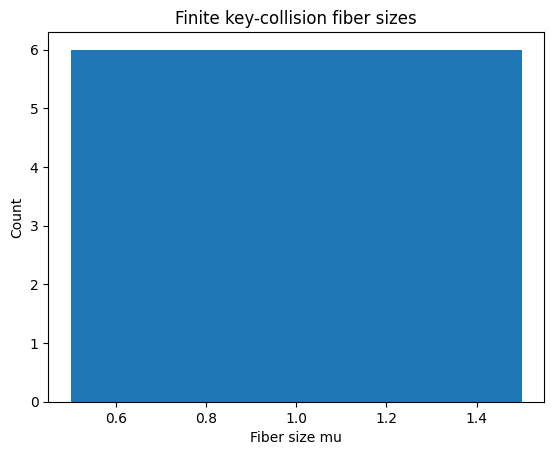

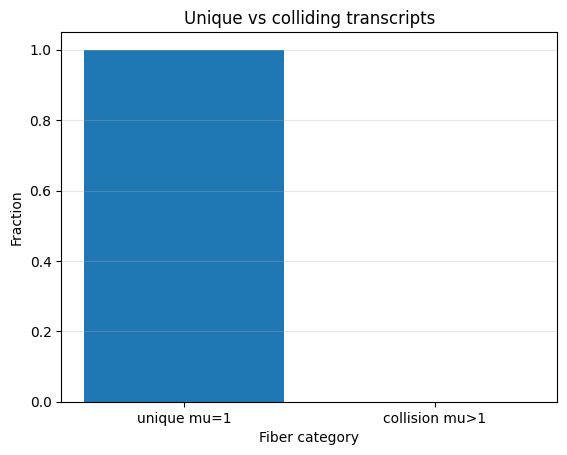

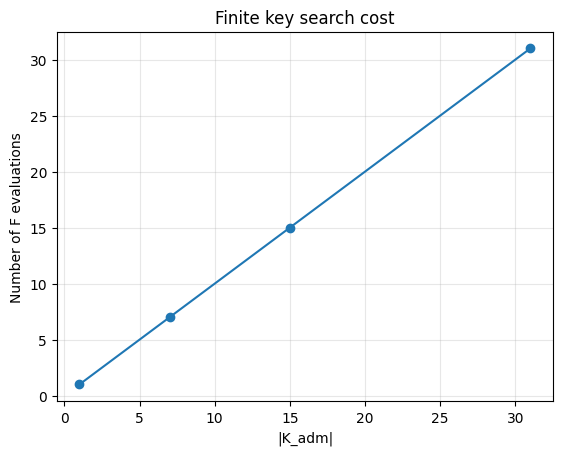

In [8]:
def build_admissible_keys():
    keys = [row["text"] for row in key_records]
    keys.extend([
        "The quick brown fox jumps.",
        "The quick brown fox jump.",
        "The quick brown fox jumps!",
        "Write about baking bred.",
        "Write about baking bread",
        "Describe a quiet mountain villlage.",
    ])
    templates = [
        "Write a short note about {topic}.",
        "Describe {topic} in plain language.",
        "Explain a scene involving {topic}.",
    ]
    topics = ["coffee", "rain", "old books", "a train station", "garden tools"]
    for template in templates:
        for topic in topics:
            keys.append(template.format(topic=topic))
    optional_path = cu.REPO_ROOT / "data" / "key_prompts.txt"
    if optional_path.exists():
        keys.extend([line.strip() for line in optional_path.read_text(encoding="utf-8").splitlines() if line.strip()])
    return list(dict.fromkeys(keys))

K_ADM = build_admissible_keys()
print("|K_adm| =", len(K_ADM))

collision_payloads = payload_records[:CONFIG["num_collision_payloads"]]
exp3_rows = []
largest_rows = []
collision_pairs = []
search_started = time.perf_counter()

for case_id, payload in enumerate(collision_payloads):
    rank_trace = cu.rank_trace_from_token_ids(llm, cu._make_prefix_ids(CONFIG["secret_prefix"], llm), payload["token_ids"])
    ranks = rank_trace["ranks"]
    true_key = K_ADM[case_id % len(K_ADM)]
    w_true = cu.F_key_on_ranks(ranks, true_key, llm, CONFIG["secret_prefix"], use_cache=True)
    candidates = []
    per_key_started = time.perf_counter()
    for candidate_key in K_ADM:
        w_candidate = cu.F_key_on_ranks(ranks, candidate_key, llm, CONFIG["secret_prefix"], use_cache=True)
        if w_candidate == w_true:
            candidates.append(candidate_key)
    elapsed = time.perf_counter() - per_key_started

    verified = True
    if len(candidates) > 1:
        for candidate_key in candidates:
            recomputed = cu.F_key_on_ranks(ranks, candidate_key, llm, CONFIG["secret_prefix"], use_cache=False)
            verified = verified and (recomputed == w_true)
        for a, b in itertools.combinations(candidates, 2):
            collision_pairs.append({
                "payload_id": payload["payload_id"],
                "payload_text": payload["text"],
                "rank_length": len(ranks),
                "key_a": a,
                "key_b": b,
                "ranks": ranks,
                "w": w_true,
            })

    row = {
        "case_id": case_id,
        "payload_id": payload["payload_id"],
        "payload_text": payload["text"],
        "rank_length": len(ranks),
        "true_key": true_key,
        "fiber_size": len(candidates),
        "candidate_keys": candidates,
        "true_key_in_candidates": true_key in candidates,
        "collisions_verified_without_cache": verified,
        "keyset_size": len(K_ADM),
        "f_evaluations": len(K_ADM),
        "search_elapsed_seconds": elapsed,
        "target_w": w_true,
    }
    exp3_rows.append(row)
    largest_rows.append({
        "payload": payload["text"],
        "key_true": true_key,
        "fiber_size": len(candidates),
        "candidate_keys": candidates,
    })

largest_rows = sorted(largest_rows, key=lambda row: row["fiber_size"], reverse=True)
cu.write_csv(cu.TABLES_DIR / "experiment3_key_collision_fibers.csv", exp3_rows)
cu.write_csv(cu.TABLES_DIR / "experiment3_largest_fibers.csv", largest_rows)
cu.write_json(cu.RAW_DIR / "experiment3_key_collision_fibers.json", {"rows": exp3_rows, "collision_pairs": collision_pairs, "K_adm": K_ADM})
record_table("experiment3_key_collision_fibers.csv", "Experiment 3", "Candidate fiber size and true-key containment for each transcript.", "Finite key-collision fibers.")
record_table("experiment3_largest_fibers.csv", "Experiment 3", "Largest observed candidate fibers.", "Finite key-collision examples.")

fiber_sizes = [row["fiber_size"] for row in exp3_rows]
cu.histogram(fiber_sizes, "exp3_fiber_size_histogram.png", "Finite key-collision fiber sizes", "Fiber size mu", bins=max(1, min(10, max(fiber_sizes or [1]))))
record_figure("exp3_fiber_size_histogram.png", "Experiment 3", "Histogram of finite candidate fiber sizes.", "Finite key-collision fiber census.")

unique_fraction = sum(1 for mu in fiber_sizes if mu == 1) / max(len(fiber_sizes), 1)
collision_fraction = sum(1 for mu in fiber_sizes if mu > 1) / max(len(fiber_sizes), 1)
cu.bar_plot(["unique mu=1", "collision mu>1"], [unique_fraction, collision_fraction], "exp3_unique_vs_collision_bar.png", "Unique vs colliding transcripts", "Fiber category", "Fraction")
record_figure("exp3_unique_vs_collision_bar.png", "Experiment 3", "Fraction of unique and colliding finite-key transcripts.", "Finite collision frequency.")

search_cost_rows = []
for size in sorted(set([1, max(1, len(K_ADM)//4), max(1, len(K_ADM)//2), len(K_ADM)])):
    search_cost_rows.append({"keyset_size": size, "f_evaluations_per_transcript": size})
cu.write_csv(cu.TABLES_DIR / "experiment3_search_cost.csv", search_cost_rows)
record_table("experiment3_search_cost.csv", "Experiment 3", "Finite key search cost in F evaluations per transcript.", "Finite context-search cost.")
cu.line_plot([row["keyset_size"] for row in search_cost_rows], [row["f_evaluations_per_transcript"] for row in search_cost_rows], "exp3_search_time_vs_keyset_size.png", "Finite key search cost", "|K_adm|", "Number of F evaluations")
record_figure("exp3_search_time_vs_keyset_size.png", "Experiment 3", "Number of F evaluations required by exhaustive finite key search.", "Finite context-search cost.")

collision_count = sum(1 for row in exp3_rows if row["fiber_size"] > 1)
largest_fiber = max(fiber_sizes or [0])
true_key_all = all(row["true_key_in_candidates"] for row in exp3_rows)
summary = (
    f"Under the finite key set K_adm of size {len(K_ADM)}, collisions occurred in {collision_count}/{len(exp3_rows)} tested transcripts. "
    f"The largest observed candidate fiber had size {largest_fiber}. The true key was contained in every candidate set: {true_key_all}. "
    "These results are finite-key results and do not characterize the infinite prompt space."
)
PAPER_BULLETS.append(summary)
cu.append_summary("Key-collision result", summary)
show_rows(exp3_rows)


# Experiment 4: Collision stability across new payloads

**Theory object tested.** This experiment asks whether a local collision `F_{k_a}(r_0) = F_{k_b}(r_0)` remains a collision on new payload rank vectors.

**Data.** Collision pairs discovered in Experiment 3. If none are found under `K_adm`, stability plots that require collisions are skipped. Candidate-set shrinkage across multiple transcripts is still measured under the same finite key set.

**Metrics.** Exact stability rate, normalized rank Hamming distance, normalized log-rank distance, and candidate-set size after multiple transcripts.

**Claim supported.** Whether single-transcript collisions appear local or stable under this finite key set and payload sample. This does not make claims about all prompts or all payloads.


No discovered collisions under this K_adm. Experiment 4 collision-stability comparison skipped.


[]

[{'num_transcripts': 1,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'num_transcripts': 2,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'num_transcripts': 3,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'num_transcripts': 4,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'num_transcripts': 5,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'num_transcripts': 6,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'num_transcripts': 7,
  'candidate_set_size': 1,
  'true_key_still_present': True},
 {'num_transcripts': 8,
  'candidate_set_size': 1,
  'true_key_still_present': True}]

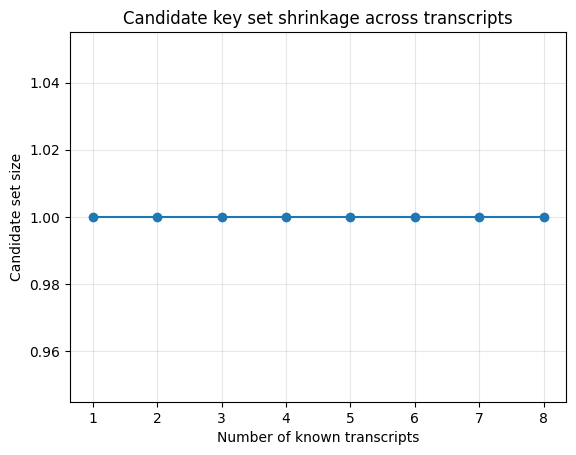

In [9]:
def rank_vectors_of_length(length_n, max_count, seed_offset=0):
    rows = []
    for payload in payload_records:
        ids = payload["token_ids"]
        if len(ids) == length_n:
            aligned_ids = ids
            source = "exact_length"
        elif len(ids) > length_n:
            aligned_ids = ids[:length_n]
            source = "truncated_to_required_length"
        else:
            continue
        trace = cu.rank_trace_from_token_ids(llm, cu._make_prefix_ids(CONFIG["secret_prefix"], llm), aligned_ids)
        rows.append({
            "payload_id": payload["payload_id"],
            "payload_text": payload["text"],
            "source": source,
            "token_ids": aligned_ids,
            "ranks": trace["ranks"],
        })
    return rows[:max_count]

exp4_rows = []
random_pair_rows = []
limited_collision_pairs = collision_pairs[: min(len(collision_pairs), 8)]

if not limited_collision_pairs:
    skip_text = "No discovered collisions under this K_adm. Experiment 4 collision-stability comparison skipped."
    print(skip_text)
    # Summary is appended after candidate-shrinkage evaluation below.
else:
    for pair_id, pair in enumerate(limited_collision_pairs):
        new_vectors = rank_vectors_of_length(pair["rank_length"], CONFIG["num_stability_payloads"])
        if not new_vectors:
            continue
        exact_hits = 0
        distances = []
        for rv in new_vectors:
            u = cu.F_key_on_ranks(rv["ranks"], pair["key_a"], llm, CONFIG["secret_prefix"], use_cache=True)
            v = cu.F_key_on_ranks(rv["ranks"], pair["key_b"], llm, CONFIG["secret_prefix"], use_cache=True)
            exact = (u == v)
            exact_hits += int(exact)
            hamming = cu.normalized_rank_hamming(u, v)
            log_distance = cu.normalized_log_rank_distance(u, v, VOCAB_SIZE or 128000)
            distances.append(log_distance)
            exp4_rows.append({
                "pair_id": pair_id,
                "pair_type": "discovered_collision_pair",
                "key_a": pair["key_a"],
                "key_b": pair["key_b"],
                "payload_id": rv["payload_id"],
                "payload_alignment": rv["source"],
                "rank_length": pair["rank_length"],
                "exact_equal": exact,
                "rank_hamming_distance": hamming,
                "log_rank_distance": log_distance,
            })
        stability_rate = exact_hits / max(len(new_vectors), 1)
        for row in exp4_rows:
            if row["pair_id"] == pair_id:
                row["exact_stability_rate_for_pair"] = stability_rate

    noncollision_candidates = []
    for a, b in itertools.combinations(K_ADM[: min(len(K_ADM), 12)], 2):
        if not any({a, b} == {pair["key_a"], pair["key_b"]} for pair in limited_collision_pairs):
            noncollision_candidates.append((a, b))
    for pair_id, (a, b) in enumerate(noncollision_candidates[: max(1, len(limited_collision_pairs))]):
        length_n = limited_collision_pairs[0]["rank_length"]
        for rv in rank_vectors_of_length(length_n, CONFIG["num_stability_payloads"]):
            u = cu.F_key_on_ranks(rv["ranks"], a, llm, CONFIG["secret_prefix"], use_cache=True)
            v = cu.F_key_on_ranks(rv["ranks"], b, llm, CONFIG["secret_prefix"], use_cache=True)
            exp4_rows.append({
                "pair_id": pair_id,
                "pair_type": "random_noncolliding_pair",
                "key_a": a,
                "key_b": b,
                "payload_id": rv["payload_id"],
                "payload_alignment": rv["source"],
                "rank_length": length_n,
                "exact_equal": u == v,
                "rank_hamming_distance": cu.normalized_rank_hamming(u, v),
                "log_rank_distance": cu.normalized_log_rank_distance(u, v, VOCAB_SIZE or 128000),
                "exact_stability_rate_for_pair": float("nan"),
            })

# Candidate shrinkage across transcripts for one true key.
shrinkage_rows = []
true_key = K_ADM[0]
candidates = set(K_ADM)
for t, payload in enumerate(payload_records[:CONFIG["num_stability_payloads"]], start=1):
    ranks = cu.rank_trace_from_token_ids(llm, cu._make_prefix_ids(CONFIG["secret_prefix"], llm), payload["token_ids"])["ranks"]
    target = cu.F_key_on_ranks(ranks, true_key, llm, CONFIG["secret_prefix"], use_cache=True)
    surviving = set()
    for candidate_key in candidates:
        if cu.F_key_on_ranks(ranks, candidate_key, llm, CONFIG["secret_prefix"], use_cache=True) == target:
            surviving.add(candidate_key)
    candidates = surviving
    shrinkage_rows.append({"num_transcripts": t, "candidate_set_size": len(candidates), "true_key_still_present": true_key in candidates})

cu.write_csv(cu.TABLES_DIR / "experiment4_collision_stability.csv", exp4_rows)
cu.write_csv(cu.TABLES_DIR / "experiment4_candidate_shrinkage.csv", shrinkage_rows)
cu.write_json(cu.RAW_DIR / "experiment4_collision_stability.json", {"stability_rows": exp4_rows, "shrinkage_rows": shrinkage_rows})
record_table("experiment4_collision_stability.csv", "Experiment 4", "Collision stability and divergence across new payload rank vectors.", "Multi-payload collision stability under finite K_adm.")
record_table("experiment4_candidate_shrinkage.csv", "Experiment 4", "Candidate set size after accumulating transcripts.", "Multi-transcript ambiguity under finite K_adm.")

if exp4_rows and any(row["pair_type"] == "discovered_collision_pair" for row in exp4_rows):
    stability_rates = sorted(set(row["exact_stability_rate_for_pair"] for row in exp4_rows if row["pair_type"] == "discovered_collision_pair" and not math.isnan(row["exact_stability_rate_for_pair"])))
    cu.histogram(stability_rates, "exp4_stability_rate_histogram.png", "Collision stability across new payloads", "Exact stability rate", bins=max(1, min(10, len(stability_rates))))
    record_figure("exp4_stability_rate_histogram.png", "Experiment 4", "Distribution of exact stability rates for discovered collision pairs.", "Local versus stable collisions.")

    distances_by_type = defaultdict(list)
    for row in exp4_rows:
        distances_by_type[row["pair_type"]].append(row["rank_hamming_distance"])
    cu.boxplot(distances_by_type, "exp4_rank_distance_boxplot.png", "Output divergence for colliding vs random key pairs", "Normalized rank Hamming distance")
    record_figure("exp4_rank_distance_boxplot.png", "Experiment 4", "Rank-output divergence for discovered collision pairs and random key pairs.", "Collision stability compared with baseline pairs.")

cu.line_plot([row["num_transcripts"] for row in shrinkage_rows], [row["candidate_set_size"] for row in shrinkage_rows], "exp4_candidate_set_size_vs_transcripts.png", "Candidate key set shrinkage across transcripts", "Number of known transcripts", "Candidate set size")
record_figure("exp4_candidate_set_size_vs_transcripts.png", "Experiment 4", "Candidate key set size after accumulating exact transcripts.", "Multi-transcript candidate shrinkage.")

if exp4_rows:
    collision_stability_values = [row["exact_stability_rate_for_pair"] for row in exp4_rows if row["pair_type"] == "discovered_collision_pair" and not math.isnan(row["exact_stability_rate_for_pair"])]
    average_stability = statistics.mean(collision_stability_values) if collision_stability_values else float("nan")
    final_candidates = shrinkage_rows[-1]["candidate_set_size"] if shrinkage_rows else float("nan")
    summary = (
        f"For discovered collision pairs, the average exact stability rate across tested same-length payload rank vectors was {average_stability:.4f}. "
        f"The finite candidate set size after {len(shrinkage_rows)} transcripts was {final_candidates}. "
        "This shows whether single-transcript collisions imply longer-term ambiguity under this finite key set."
    )
else:
    summary = "No discovered collisions under this K_adm, so collision-pair stability was skipped. Candidate shrinkage was still evaluated for the finite key set."
PAPER_BULLETS.append(summary)
cu.append_summary("Collision stability result", summary)
show_rows(exp4_rows)
show_rows(shrinkage_rows)


# Experiment 5: Non-commutativity of key-induced maps

**Theory object tested.** This experiment studies whether sampled key-induced maps commute on sampled rank vectors: `F_k(F_h(r))` versus `F_h(F_k(r))`.

**Data.** Sampled key pairs from `K_adm` and sampled payload rank vectors.

**Metrics.** Sampled exact commutation rate and normalized log-rank commutation distance.

**Plots and outputs.** Commutation-rate histogram, metric-distance CDF, key-pair heatmap, and threshold curve `N_k(tau)`.

**Claim supported.** Evidence for or against sampled related-instance commutation behavior in this tested setting. A negative result means no exact commuting pairs were found in the tested sample, not impossibility.


[{'pair_id': 0,
  'key_k': 'The quick brown fox jumps',
  'key_h': 'The quick brow fox jumps',
  'sampled_commutation_rate': 0.0,
  'mean_log_rank_commutation_distance': 0.19124198578713378,
  'num_payloads': 6},
 {'pair_id': 1,
  'key_k': 'Explain a baseball practice.',
  'key_h': 'The quick brow fox jumps',
  'sampled_commutation_rate': 0.0,
  'mean_log_rank_commutation_distance': 0.2077957775948909,
  'num_payloads': 6},
 {'pair_id': 2,
  'key_k': 'Write about baking bread.',
  'key_h': 'The quick brown fox jumps!',
  'sampled_commutation_rate': 0.0,
  'mean_log_rank_commutation_distance': 0.1554352336665524,
  'num_payloads': 6},
 {'pair_id': 3,
  'key_k': 'The quick brow fox jumps',
  'key_h': 'The quick brown fox jumps.',
  'sampled_commutation_rate': 0.0,
  'mean_log_rank_commutation_distance': 0.17890625839237356,
  'num_payloads': 6},
 {'pair_id': 4,
  'key_k': 'Describe a quiet mountain village.',
  'key_h': 'The quick brow fox jumps',
  'sampled_commutation_rate': 0.0,
  'me

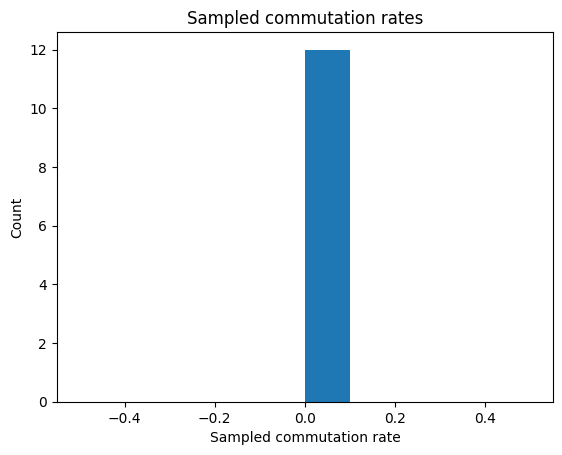

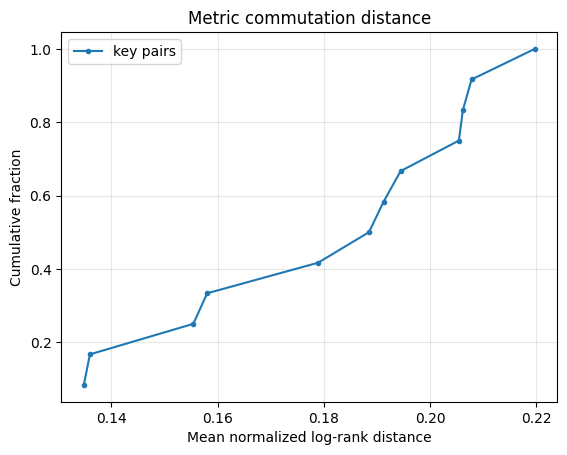

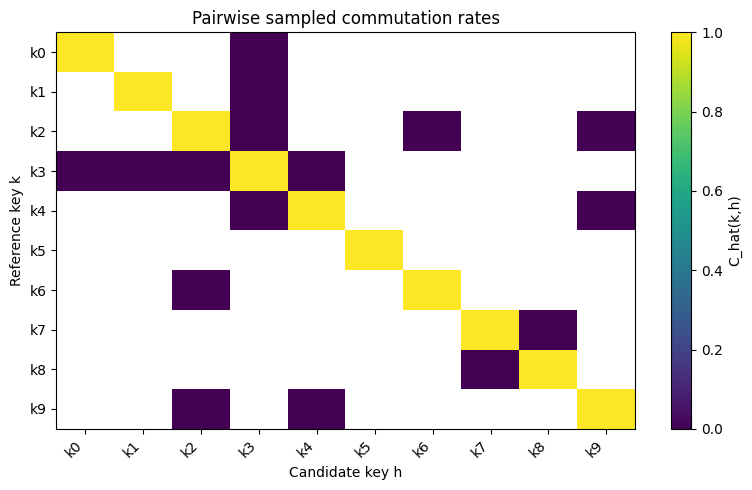

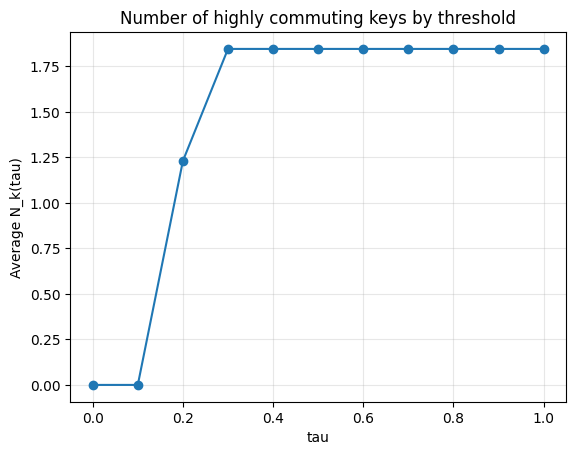

In [10]:
all_key_pairs = list(itertools.combinations(K_ADM[: min(len(K_ADM), 14)], 2))
rng = random.Random(CONFIG["random_seed"] + 5)
rng.shuffle(all_key_pairs)
sampled_key_pairs_5 = all_key_pairs[:CONFIG["num_commutativity_pairs"]]
rank_vectors_5 = []
for payload in payload_records[:CONFIG["num_commutativity_payloads"]]:
    trace = cu.rank_trace_from_token_ids(llm, cu._make_prefix_ids(CONFIG["secret_prefix"], llm), payload["token_ids"])
    rank_vectors_5.append({"payload_id": payload["payload_id"], "payload_text": payload["text"], "ranks": trace["ranks"]})

exp5_rows = []
pair_summary_5 = []
for pair_id, (k, h) in enumerate(sampled_key_pairs_5):
    exact_count = 0
    distances = []
    for rv in rank_vectors_5:
        fk_fh = cu.F_key_on_ranks(cu.F_key_on_ranks(rv["ranks"], h, llm, CONFIG["secret_prefix"], use_cache=True), k, llm, CONFIG["secret_prefix"], use_cache=True)
        fh_fk = cu.F_key_on_ranks(cu.F_key_on_ranks(rv["ranks"], k, llm, CONFIG["secret_prefix"], use_cache=True), h, llm, CONFIG["secret_prefix"], use_cache=True)
        exact = fk_fh == fh_fk
        distance = cu.normalized_log_rank_distance(fk_fh, fh_fk, VOCAB_SIZE or 128000)
        exact_count += int(exact)
        distances.append(distance)
        exp5_rows.append({
            "pair_id": pair_id,
            "key_k": k,
            "key_h": h,
            "payload_id": rv["payload_id"],
            "rank_length": len(rv["ranks"]),
            "exact_commutes_on_payload": exact,
            "log_rank_commutation_distance": distance,
        })
    pair_summary_5.append({
        "pair_id": pair_id,
        "key_k": k,
        "key_h": h,
        "sampled_commutation_rate": exact_count / max(len(rank_vectors_5), 1),
        "mean_log_rank_commutation_distance": statistics.mean(distances) if distances else float("nan"),
        "num_payloads": len(rank_vectors_5),
    })

cu.write_csv(cu.TABLES_DIR / "experiment5_noncommutativity.csv", pair_summary_5)
cu.write_json(cu.RAW_DIR / "experiment5_noncommutativity.json", {"rows": exp5_rows, "pair_summary": pair_summary_5})
record_table("experiment5_noncommutativity.csv", "Experiment 5", "Sampled commutation rates and distances for key-induced maps.", "Non-commutativity of F_k maps.")

cu.histogram([row["sampled_commutation_rate"] for row in pair_summary_5], "exp5_commutation_rate_histogram.png", "Sampled commutation rates", "Sampled commutation rate", bins=10)
record_figure("exp5_commutation_rate_histogram.png", "Experiment 5", "Histogram of sampled exact commutation rates for key pairs.", "Non-commutativity in tested key pairs.")

cu.empirical_cdf({"key pairs": [row["mean_log_rank_commutation_distance"] for row in pair_summary_5]}, "exp5_commutation_distance_cdf.png", "Metric commutation distance", "Mean normalized log-rank distance")
record_figure("exp5_commutation_distance_cdf.png", "Experiment 5", "Empirical CDF of metric commutation distances.", "Metric non-commutativity in tested key pairs.")

heat_keys = list(dict.fromkeys([row["key_k"] for row in pair_summary_5] + [row["key_h"] for row in pair_summary_5]))[:10]
index = {key: idx for idx, key in enumerate(heat_keys)}
heat = np.full((len(heat_keys), len(heat_keys)), np.nan)
for row in pair_summary_5:
    if row["key_k"] in index and row["key_h"] in index:
        i = index[row["key_k"]]
        j = index[row["key_h"]]
        heat[i, j] = row["sampled_commutation_rate"]
        heat[j, i] = row["sampled_commutation_rate"]
np.fill_diagonal(heat, 1.0)
cu.heatmap(heat, "exp5_commutation_heatmap.png", "Pairwise sampled commutation rates", "Candidate key h", "Reference key k", xticklabels=[f"k{i}" for i in range(len(heat_keys))], yticklabels=[f"k{i}" for i in range(len(heat_keys))], colorbar_label="C_hat(k,h)", vmin=0.0, vmax=1.0)
record_figure("exp5_commutation_heatmap.png", "Experiment 5", "Heatmap of sampled commutation rates among displayed keys.", "Pairwise non-commutativity structure.")

taus = np.linspace(0.0, 1.0, 11)
threshold_rows = []
for tau in taus:
    counts_by_k = defaultdict(int)
    seen_by_k = defaultdict(int)
    for row in pair_summary_5:
        for key in [row["key_k"], row["key_h"]]:
            seen_by_k[key] += 1
            if row["mean_log_rank_commutation_distance"] <= tau:
                counts_by_k[key] += 1
    avg_count = statistics.mean(counts_by_k[key] for key in seen_by_k) if seen_by_k else 0.0
    threshold_rows.append({"tau": float(tau), "average_N_k_tau": avg_count})
cu.write_csv(cu.TABLES_DIR / "experiment5_Nk_tau_curve.csv", threshold_rows)
record_table("experiment5_Nk_tau_curve.csv", "Experiment 5", "Average number of highly commuting keys by metric threshold.", "Related-instance commutation structure.")
cu.line_plot([row["tau"] for row in threshold_rows], [row["average_N_k_tau"] for row in threshold_rows], "exp5_Nk_tau_curve.png", "Number of highly commuting keys by threshold", "tau", "Average N_k(tau)")
record_figure("exp5_Nk_tau_curve.png", "Experiment 5", "Average number of key partners below a metric commutation threshold.", "Related-instance threshold behavior.")

exact_pairs = sum(1 for row in pair_summary_5 if row["sampled_commutation_rate"] == 1.0)
median_distance = statistics.median([row["mean_log_rank_commutation_distance"] for row in pair_summary_5]) if pair_summary_5 else float("nan")
summary = (
    f"Exact sampled commuting pairs observed: {exact_pairs}/{len(pair_summary_5)}. "
    f"The median metric commutation distance was {median_distance:.4f}. "
    "These results provide evidence about the related-instance hypothesis only in the tested setting."
)
PAPER_BULLETS.append(summary)
cu.append_summary("Non-commutativity result", summary)
show_rows(pair_summary_5)


# Experiment 6: Robustness to token perturbations

**Theory object tested.** Base CARTS is exact when the stegotext token sequence is unchanged. This experiment tests brittleness when the stegotext is modified before decoding.

**Data.** Generated stegotexts from sampled payload-key pairs.

**Perturbations.** Length-preserving random token substitution, nearby-rank token substitution, and adjacent-token transposition. Insertions/deletions are not run by default because the base decoder expects a fixed-length sequence.

**Metrics.** Decoded token edit distance, first mismatch position, suffix corruption fraction, perturbation position, and token agreement after the perturbation position.

**Claim supported.** Base CARTS is exact but not robust to token perturbations without redundancy or error correction, under the perturbations tested here.


[{'case_id': 0,
  'payload_id': 3,
  'key_id': 2,
  'payload_text': 'A quiet river crossed the valley.',
  'key_text': 'Talk about animals in a forest.',
  'perturbation_type': 'random_token_substitution',
  'perturbation_position': 3,
  'token_length': 7,
  'decoded_token_edit_distance': 4,
  'normalized_decoded_token_edit_distance': 0.5714285714285714,
  'first_mismatch_position': 3,
  'suffix_corruption_fraction': 1.0,
  'original_stegotext': 'Pressed backwards/extension of fingers to',
  'perturbed_stegotext': 'Pressed backwards/ Welcome of fingers to',
  'decoded_original': ' A quiet river crossed the valley.',
  'decoded_perturbed': ' A quiet river Nin:\nSlow flows'},
 {'case_id': 0,
  'payload_id': 3,
  'key_id': 2,
  'payload_text': 'A quiet river crossed the valley.',
  'key_text': 'Talk about animals in a forest.',
  'perturbation_type': 'nearby_rank_substitution',
  'perturbation_position': 4,
  'token_length': 7,
  'decoded_token_edit_distance': 3,
  'normalized_decoded_tok

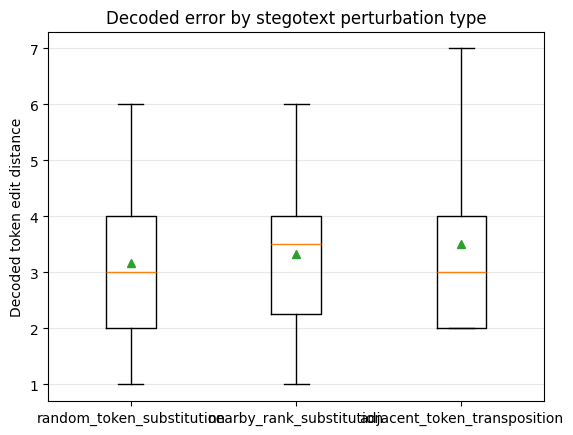

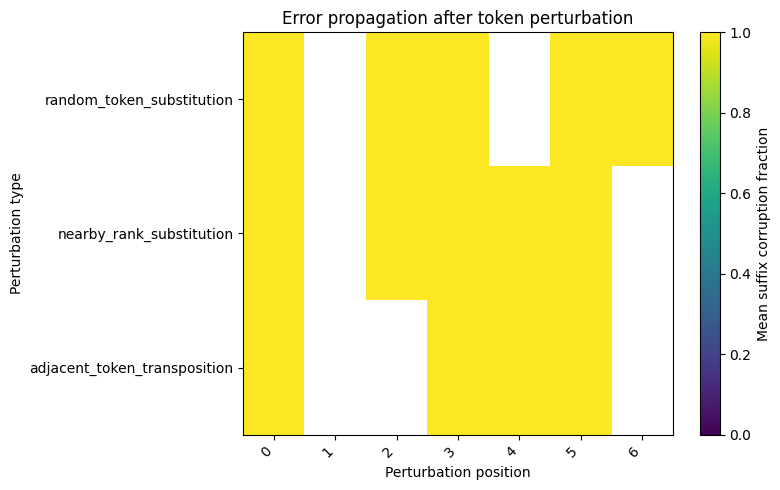

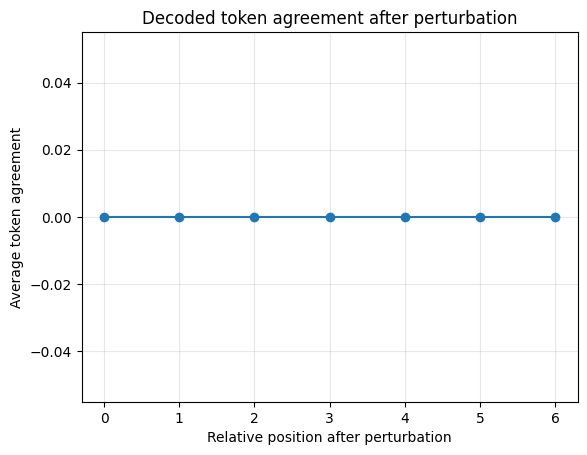

In [11]:
def token_at_rank_after_prefix(key_text, prefix_ids, rank):
    model = llm
    model.reset()
    model.eval(cu._make_prefix_ids(key_text, model))
    for token_id in prefix_ids:
        model.eval([int(token_id)])
    logits = np.asarray(model.scores[model.n_tokens - 1], dtype=np.float64)
    return cu.token_at_rank(logits, int(rank))


def perturb_stegotext(stego_ids, key_text, stego_ranks, perturbation_type, seed):
    rng = random.Random(seed)
    ids = list(map(int, stego_ids))
    if not ids:
        return ids, None, "empty_sequence"
    position = rng.randrange(len(ids))
    if perturbation_type == "random_token_substitution":
        vocab = VOCAB_SIZE or 128000
        replacement = (ids[position] + 7919 + seed) % vocab
        if replacement == ids[position]:
            replacement = (replacement + 1) % vocab
        ids[position] = int(replacement)
    elif perturbation_type == "nearby_rank_substitution":
        current_rank = int(stego_ranks[position])
        near_rank = current_rank + 1 if (VOCAB_SIZE is None or current_rank < VOCAB_SIZE) else max(1, current_rank - 1)
        replacement = token_at_rank_after_prefix(key_text, ids[:position], near_rank)
        if replacement == ids[position] and near_rank > 1:
            replacement = token_at_rank_after_prefix(key_text, ids[:position], near_rank - 1)
        ids[position] = int(replacement)
    elif perturbation_type == "adjacent_token_transposition":
        if len(ids) < 2:
            return ids, position, "too_short_for_transposition"
        if position == len(ids) - 1:
            position -= 1
        ids[position], ids[position + 1] = ids[position + 1], ids[position]
    else:
        raise ValueError(f"Unknown perturbation type: {perturbation_type}")
    return ids, position, "ok"

perturbation_types = ["random_token_substitution", "nearby_rank_substitution", "adjacent_token_transposition"]
exp6_rows = []
agreement_by_type_offset = defaultdict(list)
heat_accumulator = defaultdict(list)

for case_id, (payload, key) in enumerate(sampled_payload_key_pairs(CONFIG["num_robustness_cases"])):
    encoded = cu.E_key_token_ids(llm, payload["token_ids"], key["text"], CONFIG["secret_prefix"])
    decoded_original = cu.D_key_token_ids(llm, encoded["stegotext_ids"], key["text"], CONFIG["secret_prefix"])
    if not cu.exact_match(decoded_original["decoded_ids"], payload["token_ids"]):
        continue
    stego_trace = cu.rank_trace_from_token_ids(llm, cu._make_prefix_ids(key["text"], llm), encoded["stegotext_ids"])
    for ptype in perturbation_types:
        perturbed_ids, position, status = perturb_stegotext(encoded["stegotext_ids"], key["text"], stego_trace["ranks"], ptype, CONFIG["random_seed"] + case_id * 100 + len(ptype))
        if status != "ok":
            continue
        decoded_perturbed = cu.D_key_token_ids(llm, perturbed_ids, key["text"], CONFIG["secret_prefix"])
        edit = cu.token_edit_distance(payload["token_ids"], decoded_perturbed["decoded_ids"])
        norm_edit = cu.normalized_token_edit_distance(payload["token_ids"], decoded_perturbed["decoded_ids"])
        mismatch = cu.first_mismatch_position(payload["token_ids"], decoded_perturbed["decoded_ids"])
        suffix_fraction = cu.suffix_corruption_fraction(payload["token_ids"], decoded_perturbed["decoded_ids"])
        row = {
            "case_id": case_id,
            "payload_id": payload["payload_id"],
            "key_id": key["key_id"],
            "payload_text": payload["text"],
            "key_text": key["text"],
            "perturbation_type": ptype,
            "perturbation_position": position,
            "token_length": len(payload["token_ids"]),
            "decoded_token_edit_distance": edit,
            "normalized_decoded_token_edit_distance": norm_edit,
            "first_mismatch_position": mismatch,
            "suffix_corruption_fraction": suffix_fraction,
            "original_stegotext": encoded["stegotext_text"],
            "perturbed_stegotext": cu.safe_detokenize(perturbed_ids, llm),
            "decoded_original": decoded_original["decoded_text"],
            "decoded_perturbed": decoded_perturbed["decoded_text"],
        }
        exp6_rows.append(row)
        heat_accumulator[(ptype, position)].append(suffix_fraction)
        for offset in range(max(0, len(payload["token_ids"]) - position)):
            idx = position + offset
            agreement = int(idx < len(decoded_perturbed["decoded_ids"]) and payload["token_ids"][idx] == decoded_perturbed["decoded_ids"][idx])
            agreement_by_type_offset[(ptype, offset)].append(agreement)

cu.write_csv(cu.TABLES_DIR / "experiment6_robustness.csv", exp6_rows)
cu.write_json(cu.RAW_DIR / "experiment6_robustness.json", exp6_rows)
record_table("experiment6_robustness.csv", "Experiment 6", "Decoded errors after length-preserving stegotext token perturbations.", "Perturbation brittleness of base CARTS.")

if exp6_rows:
    edit_by_type = defaultdict(list)
    for row in exp6_rows:
        edit_by_type[row["perturbation_type"]].append(row["decoded_token_edit_distance"])
    cu.boxplot(edit_by_type, "exp6_decoded_edit_distance_by_perturbation.png", "Decoded error by stegotext perturbation type", "Decoded token edit distance")
    record_figure("exp6_decoded_edit_distance_by_perturbation.png", "Experiment 6", "Decoded token edit distance by length-preserving perturbation type.", "Perturbation brittleness.")

    max_position = max(row["perturbation_position"] for row in exp6_rows)
    heat = np.full((len(perturbation_types), max_position + 1), np.nan)
    for i, ptype in enumerate(perturbation_types):
        for pos in range(max_position + 1):
            values = heat_accumulator.get((ptype, pos), [])
            if values:
                heat[i, pos] = statistics.mean(values)
    cu.heatmap(heat, "exp6_perturb_position_vs_error_heatmap.png", "Error propagation after token perturbation", "Perturbation position", "Perturbation type", xticklabels=[str(i) for i in range(max_position + 1)], yticklabels=perturbation_types, colorbar_label="Mean suffix corruption fraction", vmin=0.0, vmax=1.0)
    record_figure("exp6_perturb_position_vs_error_heatmap.png", "Experiment 6", "Mean suffix corruption fraction by perturbation type and position.", "Error propagation after perturbation.")

    max_offset = max(offset for (_, offset) in agreement_by_type_offset.keys()) if agreement_by_type_offset else 0
    offsets = list(range(max_offset + 1))
    agreement_values = []
    for offset in offsets:
        values = []
        for ptype in perturbation_types:
            values.extend(agreement_by_type_offset.get((ptype, offset), []))
        agreement_values.append(statistics.mean(values) if values else float("nan"))
    cu.line_plot(offsets, agreement_values, "exp6_token_agreement_after_perturbation.png", "Decoded token agreement after perturbation", "Relative position after perturbation", "Average token agreement")
    record_figure("exp6_token_agreement_after_perturbation.png", "Experiment 6", "Average decoded token agreement after the perturbation position.", "Error propagation after perturbation.")

avg_edit = statistics.mean([row["decoded_token_edit_distance"] for row in exp6_rows]) if exp6_rows else float("nan")
summary = (
    f"A single length-preserving token perturbation caused average decoded edit distance {avg_edit:.4f} over {len(exp6_rows)} tested perturbations. "
    "Errors typically began at or after the perturbation position when the first mismatch was defined. "
    "This supports the claim that base CARTS is exact but not robust without redundancy or error correction under these perturbation types."
)
PAPER_BULLETS.append(summary)
cu.append_summary("Robustness result", summary)
show_rows(exp6_rows)


# Optional and future experiments

These sections are not run by default. They are included to make future extensions visible without changing the core six-experiment protocol.

## Optional A: Key-length cardinality toy regimes

Purpose: illustrate a finite cardinality corollary in a small toy setting. This should use very small rank length `n` and a small key alphabet. Label any output as a toy finite demonstration, not a full-scale Llama 3 8B security estimate.

## Optional B: Key sensitivity and avalanche-style behavior

Purpose: measure whether small prompt changes produce large `F_k` output changes. Useful plots include key edit distance versus output rank distance and pairwise distance heatmaps among perturbed keys.

## Optional C: Wrong-key decoding and restricted equivocation

Purpose: measure whether wrong-key decodes look plausible. Do not run by default without an explicit plausibility metric, threshold, calibration protocol, and human or model-judge details.

## Optional D: Advanced context-search baselines

Purpose: try heuristic key ranking before exact search. Keep exact candidate sets separate from heuristic rankings, and report true-key rank under the heuristic.


In [12]:
RUN_OPTIONAL_TOY_CARDINALITY = False
RUN_OPTIONAL_KEY_SENSITIVITY = False
RUN_OPTIONAL_WRONG_KEY_EQUIVOCATION = False
RUN_OPTIONAL_CONTEXT_SEARCH_BASELINES = False

if RUN_OPTIONAL_TOY_CARDINALITY:
    print("Toy cardinality experiment hook. Keep n and key alphabet very small and label output as toy only.")
if RUN_OPTIONAL_KEY_SENSITIVITY:
    print("Key sensitivity experiment hook. Reuse F_key_on_ranks and normalized rank distances.")
if RUN_OPTIONAL_WRONG_KEY_EQUIVOCATION:
    print("Wrong-key equivocation requires an explicit plausibility metric before running.")
if RUN_OPTIONAL_CONTEXT_SEARCH_BASELINES:
    print("Heuristic context-search baselines should be reported separately from exact candidate sets.")


# Paper verification checklist and final outputs

This final section writes the figure/table manifests, completes the Markdown summary, emits a checklist linking theory claims to experiments, and prints paper-ready bullets. It also displays all saved figures when running in a notebook frontend.


CSV files:
 - /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/tables/experiment1_correctness.csv
 - /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/tables/experiment2_rank_likelihood_detection.csv
 - /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/tables/experiment3_key_collision_fibers.csv
 - /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/tables/experiment3_largest_fibers.csv
 - /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/tables/experiment3_search_cost.csv
 - /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/tables/experiment4_candidate_shrinkage.csv
 - /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/tables/experiment4_collision_stability.csv
 - /home/meow/Documents/repos/LlmStenoExplore/paper-empirical-explorations/results/tables/experiment5_Nk_tau_curve.csv
 -

[{'Theory claim': 'Exact invertibility',
  'Experiment supporting it': 'Experiment 1',
  'Figure/table produced': 'experiment1_correctness.csv, exp1_correctness_bar.png',
  'Result summary': 'Exact recovery succeeded in 8/8 payload-key pairs under Llama 3 8B with the specified deterministic settings. Reverse-direction recovery succeeded in 8/8 cases.',
  'Caveat': 'Only verifies implementation samples; theorem is mathematical.'},
 {'Theory claim': 'Rank pressure and quality',
  'Experiment supporting it': 'Experiment 2',
  'Figure/table produced': 'exp2_nll_boxplot.png, exp2_mean_log_rank_cdf.png, exp2_tail_rank_vs_nll.png',
  'Result summary': 'CARTS stegotexts had mean normalized NLL 7.5874 compared with 0.8995 for ordinary greedy generation. The mean log-rank distribution shift was 4.2083. A simple detector achieved AUC 1.0000 under this comparison distribution. This is not a proof of steganographic distinguishability in general; it is only for this model, payload distribution, key 

### exp1_correctness_bar.png

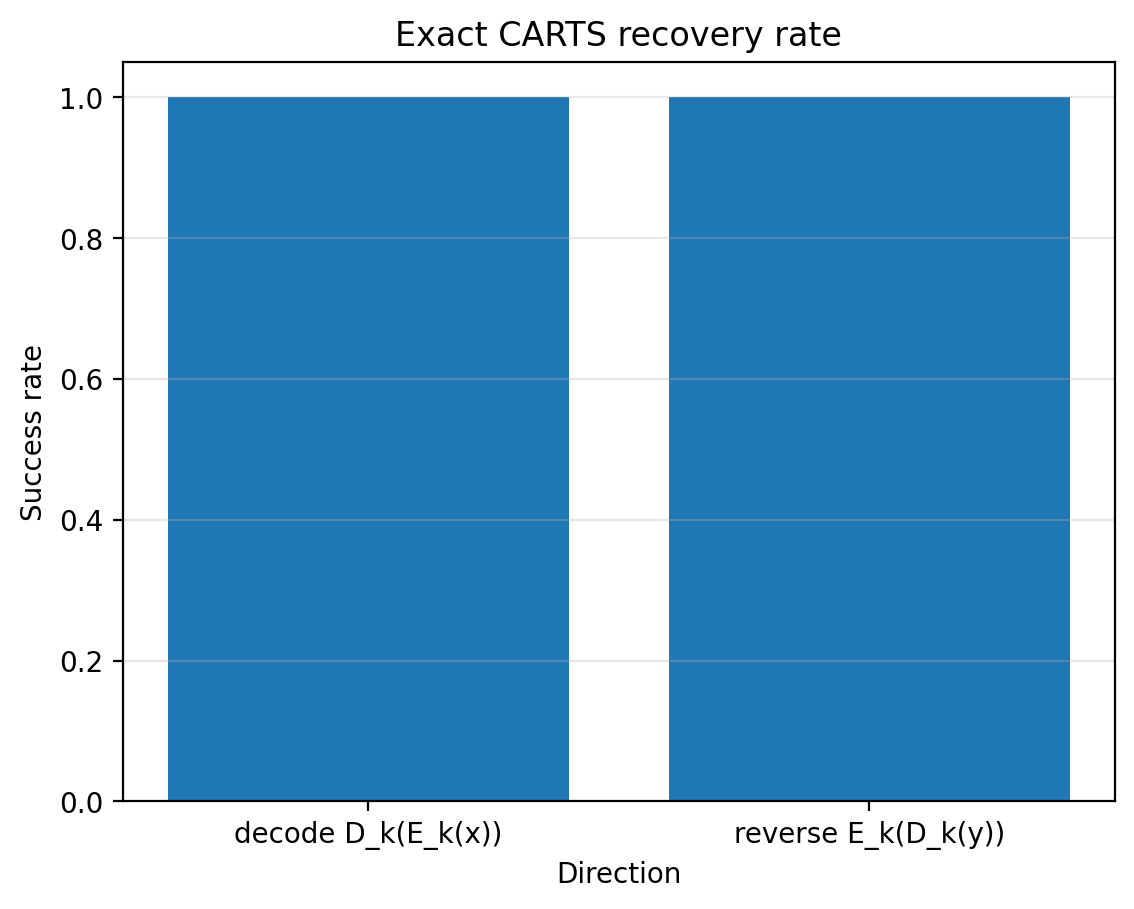

### exp2_detector_roc.png

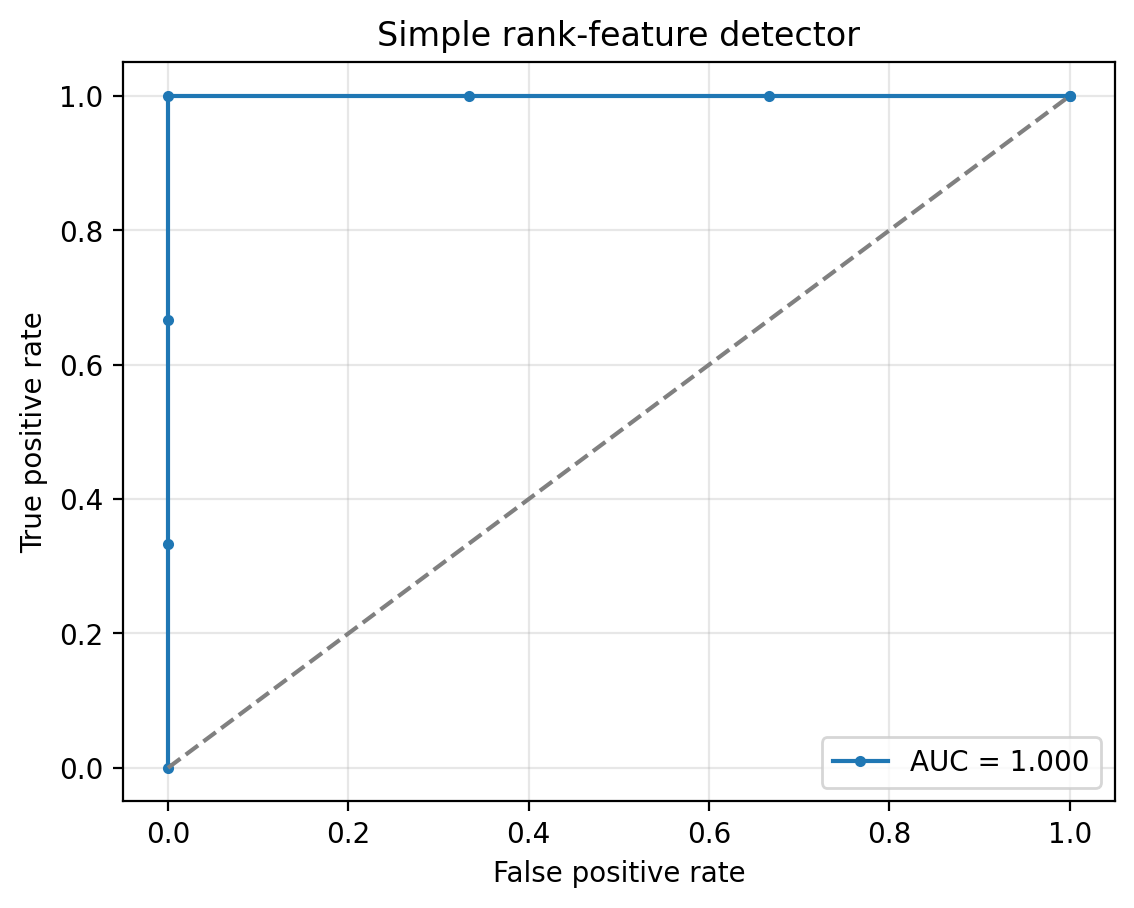

### exp2_mean_log_rank_cdf.png

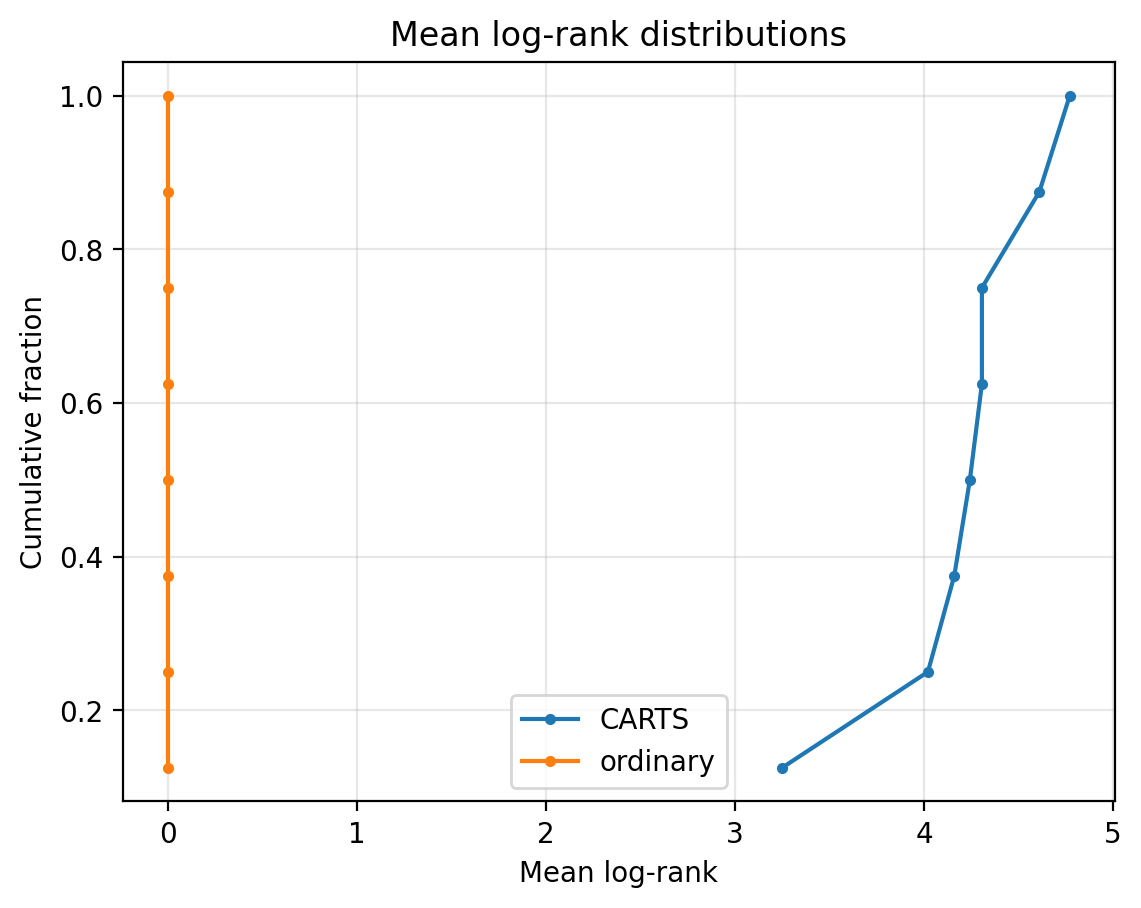

### exp2_nll_boxplot.png

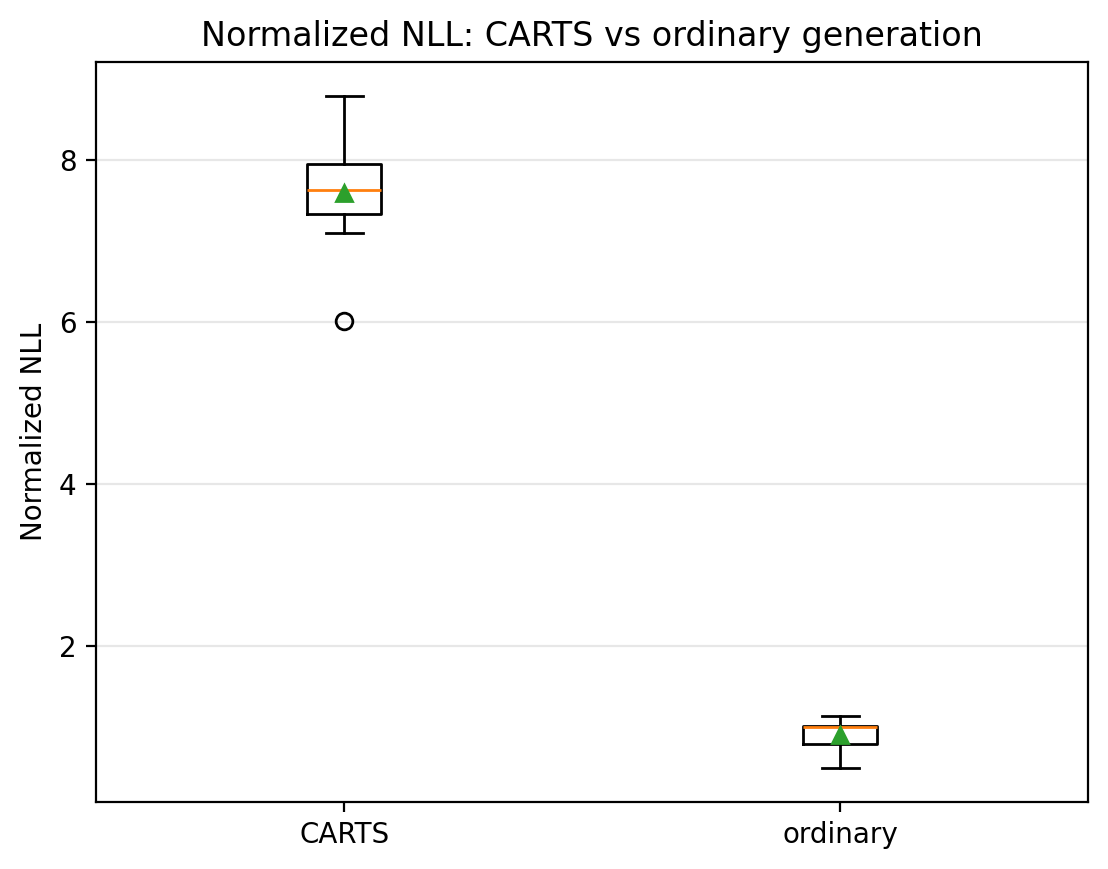

### exp2_positionwise_mean_log_rank_heatmap.png

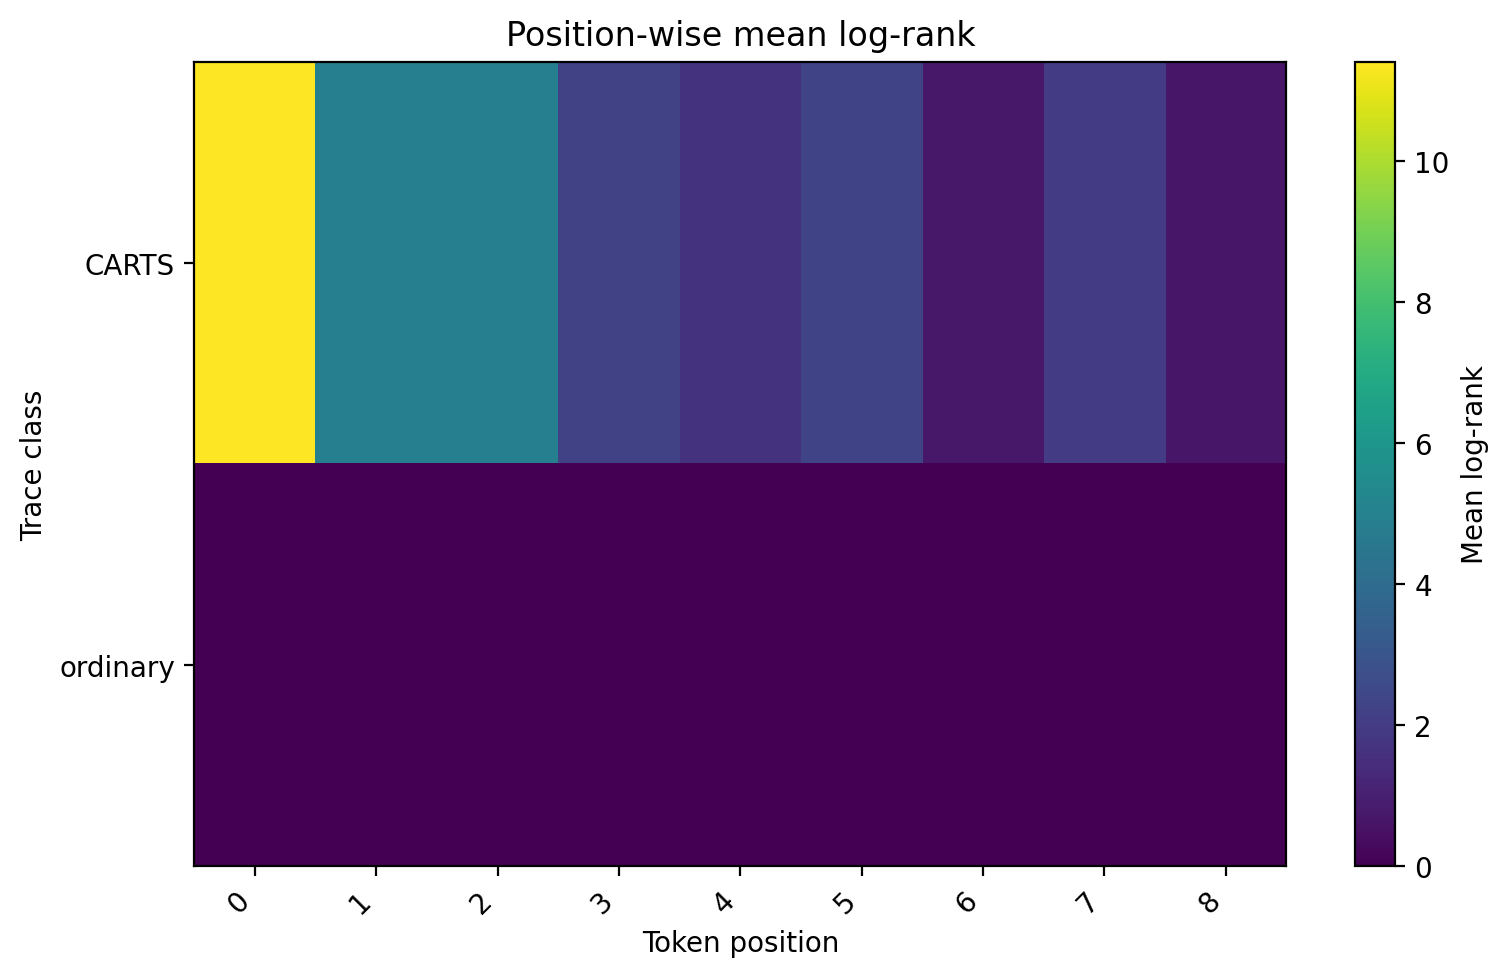

### exp2_tail_rank_vs_nll.png

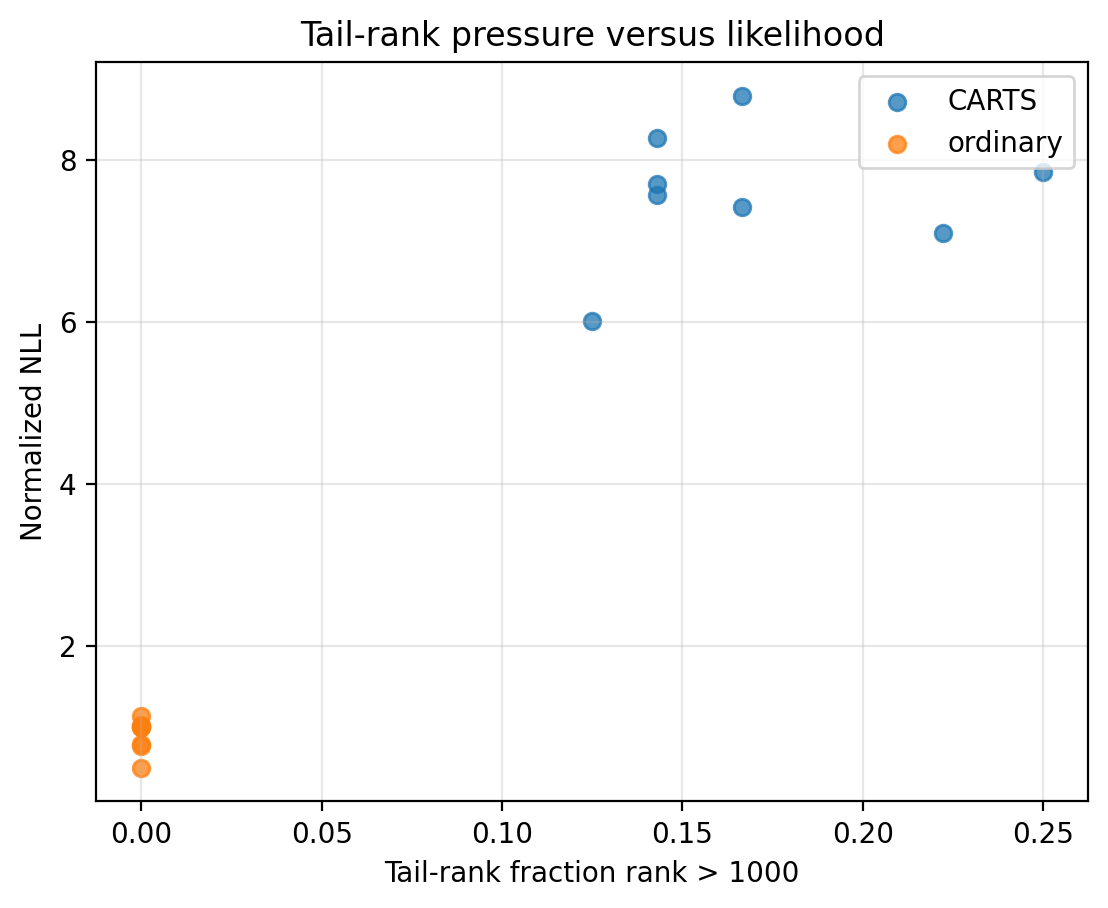

### exp3_fiber_size_histogram.png

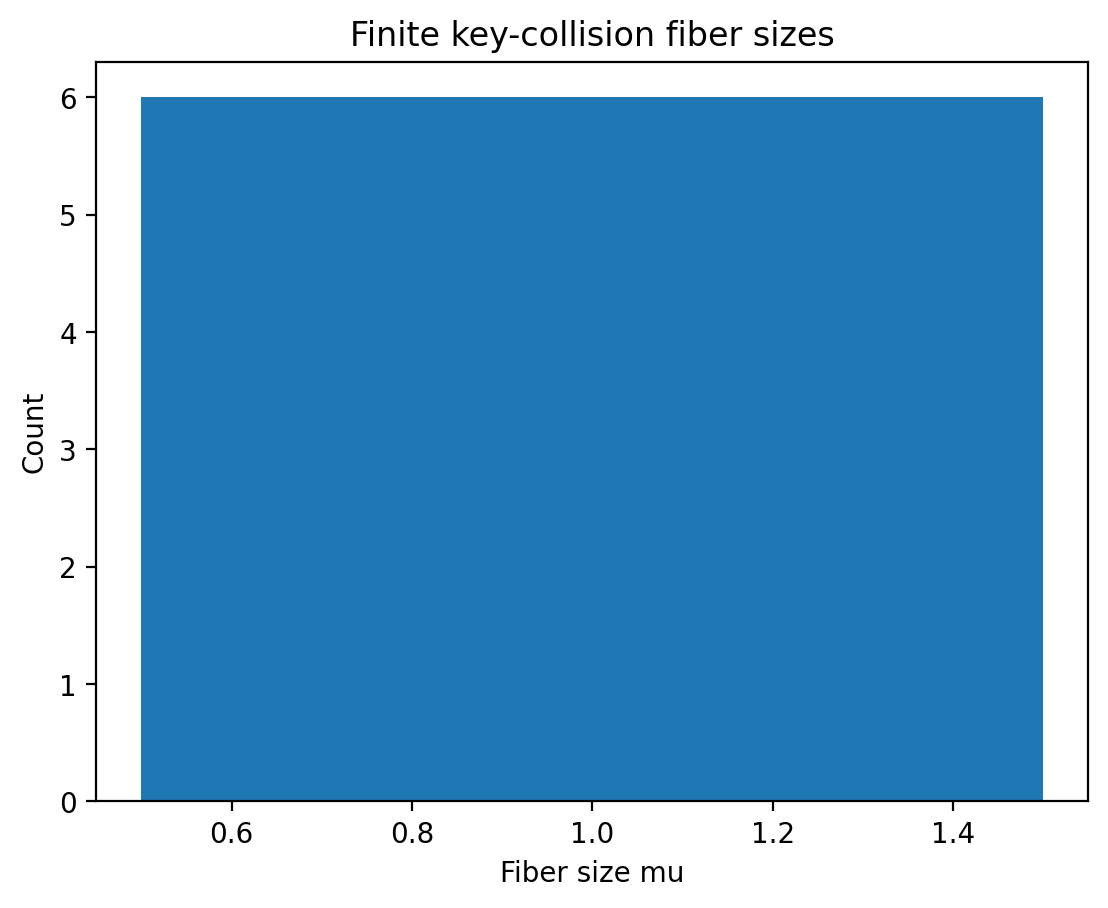

### exp3_search_time_vs_keyset_size.png

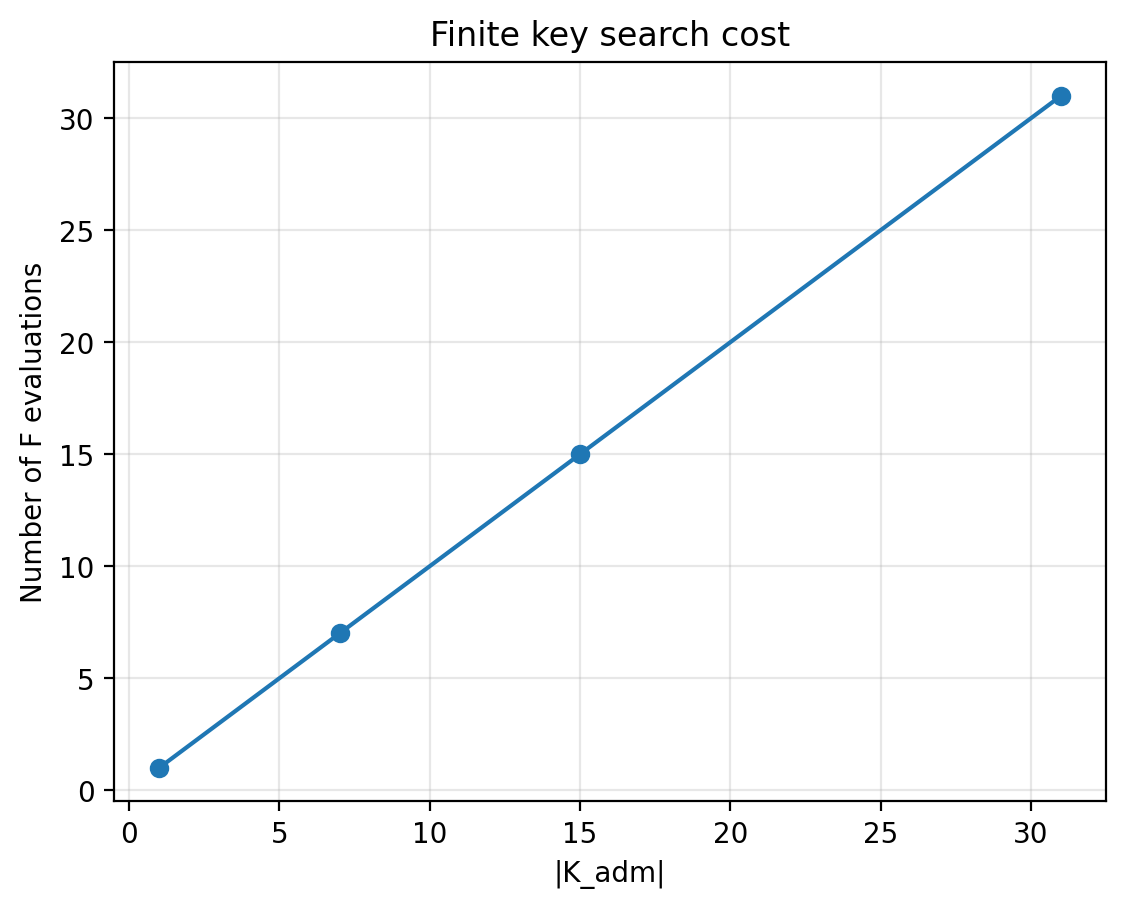

### exp3_unique_vs_collision_bar.png

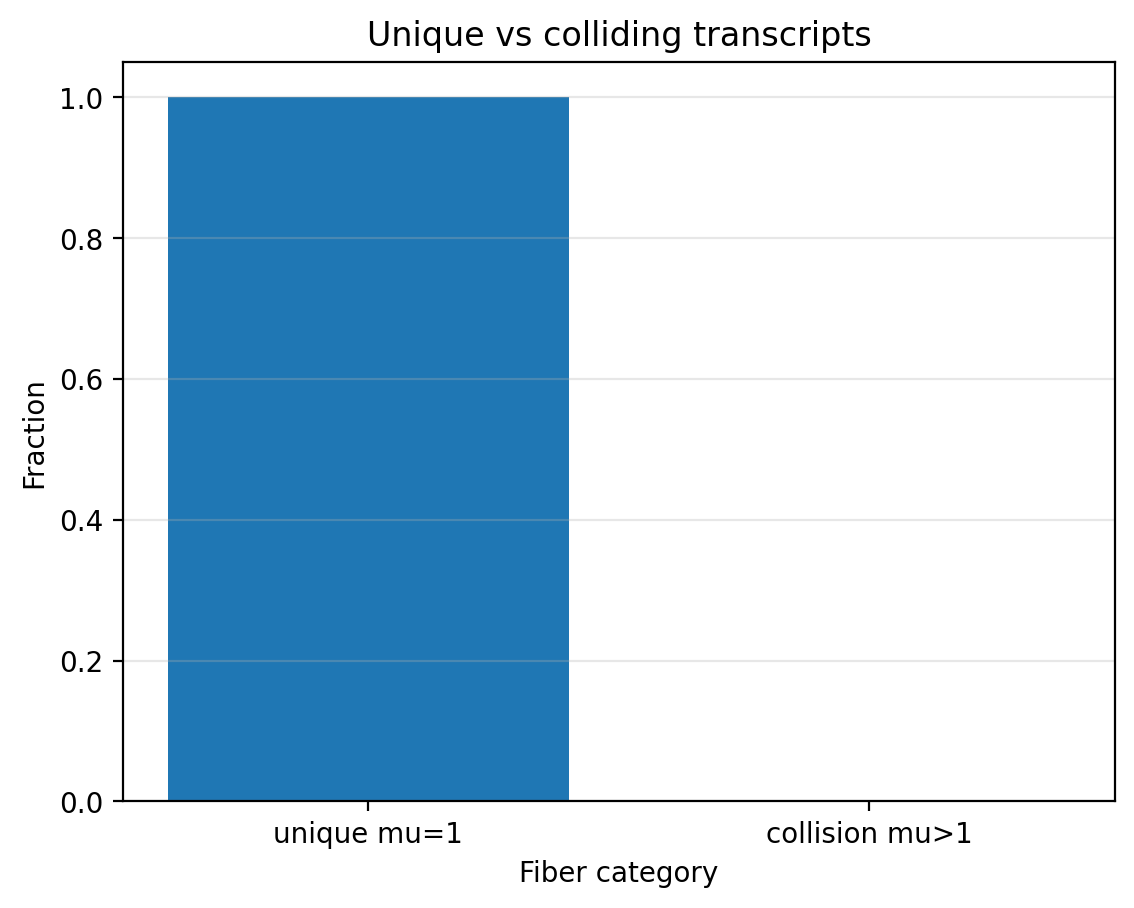

### exp4_candidate_set_size_vs_transcripts.png

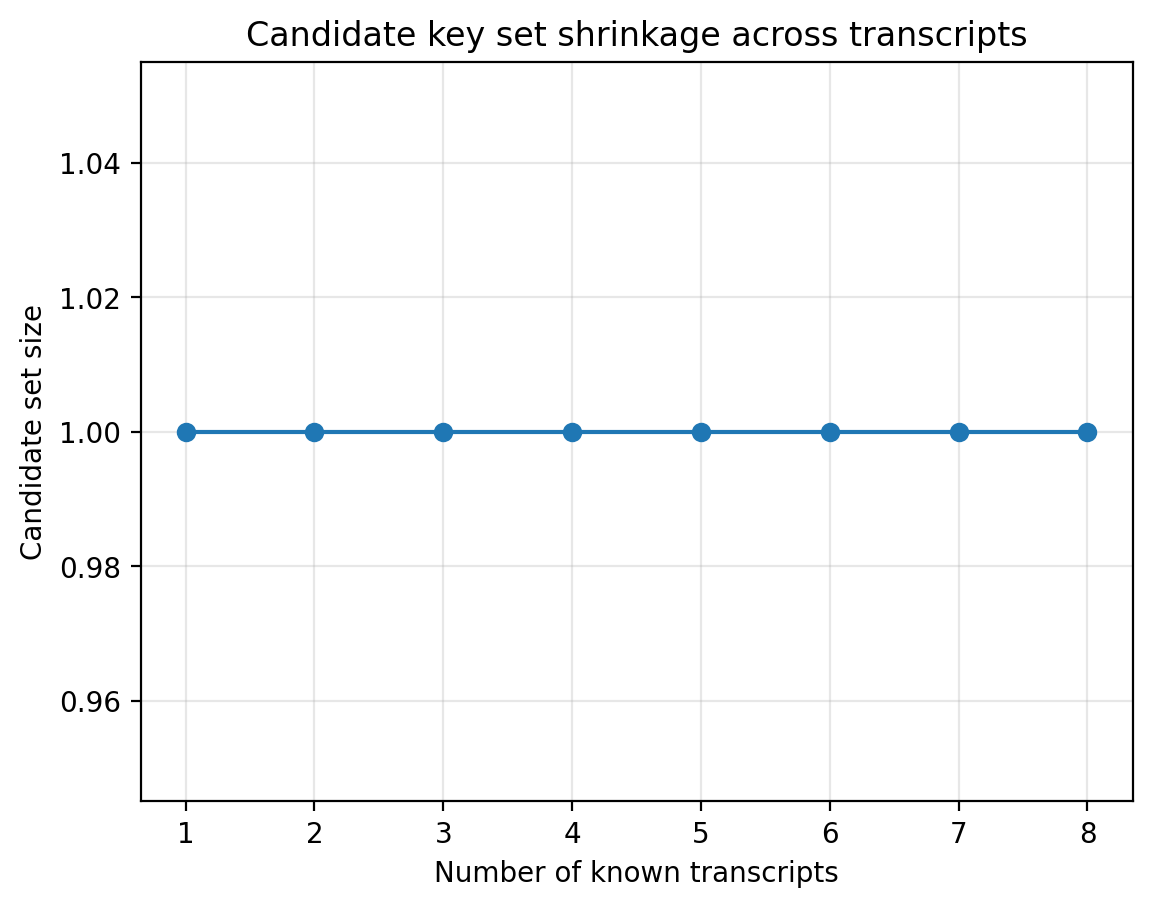

### exp5_Nk_tau_curve.png

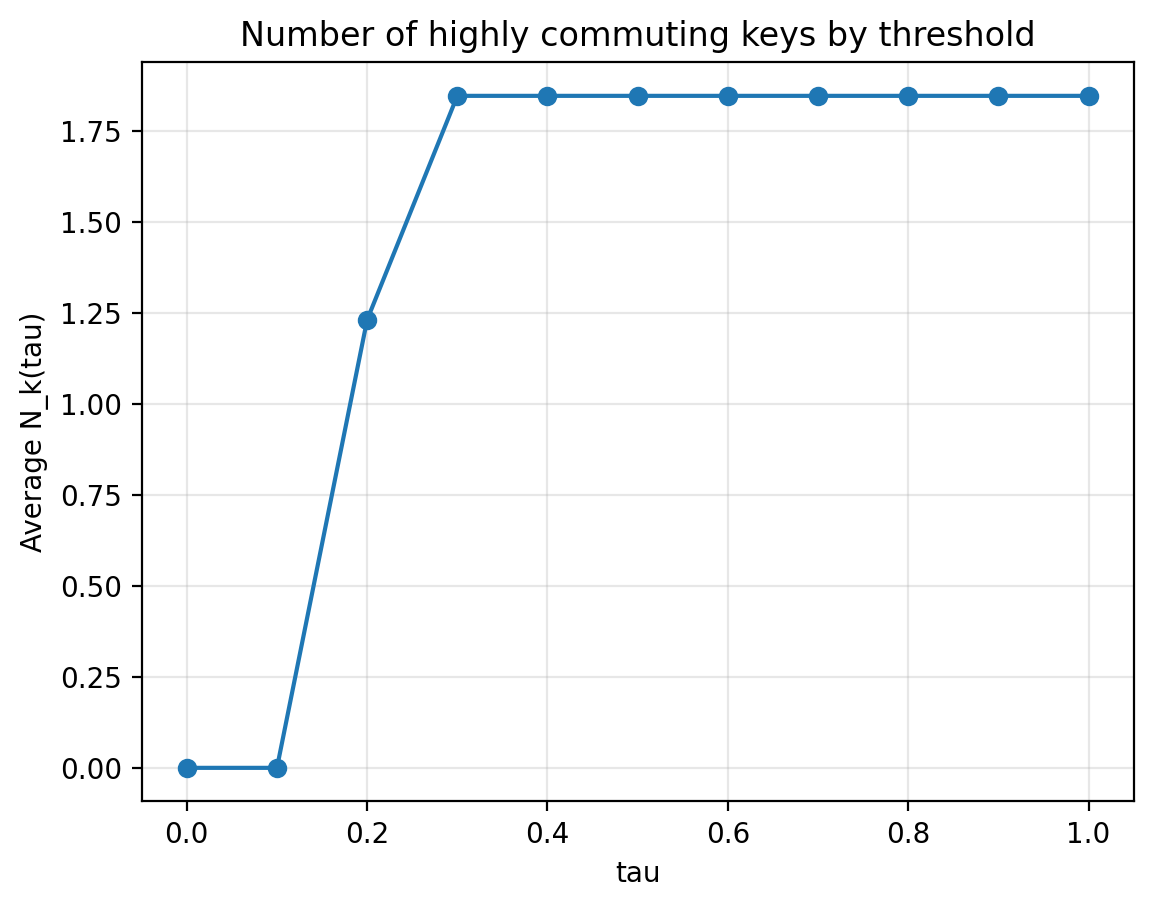

### exp5_commutation_distance_cdf.png

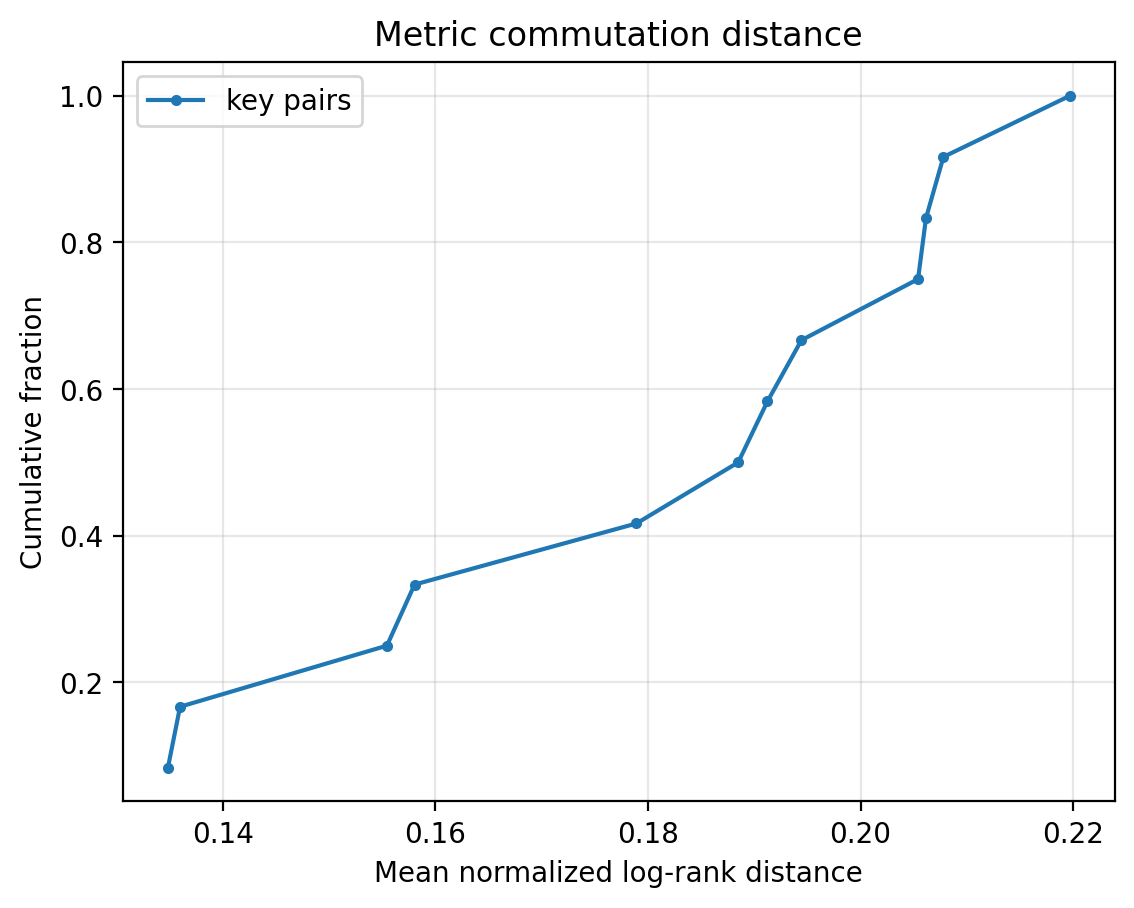

### exp5_commutation_heatmap.png

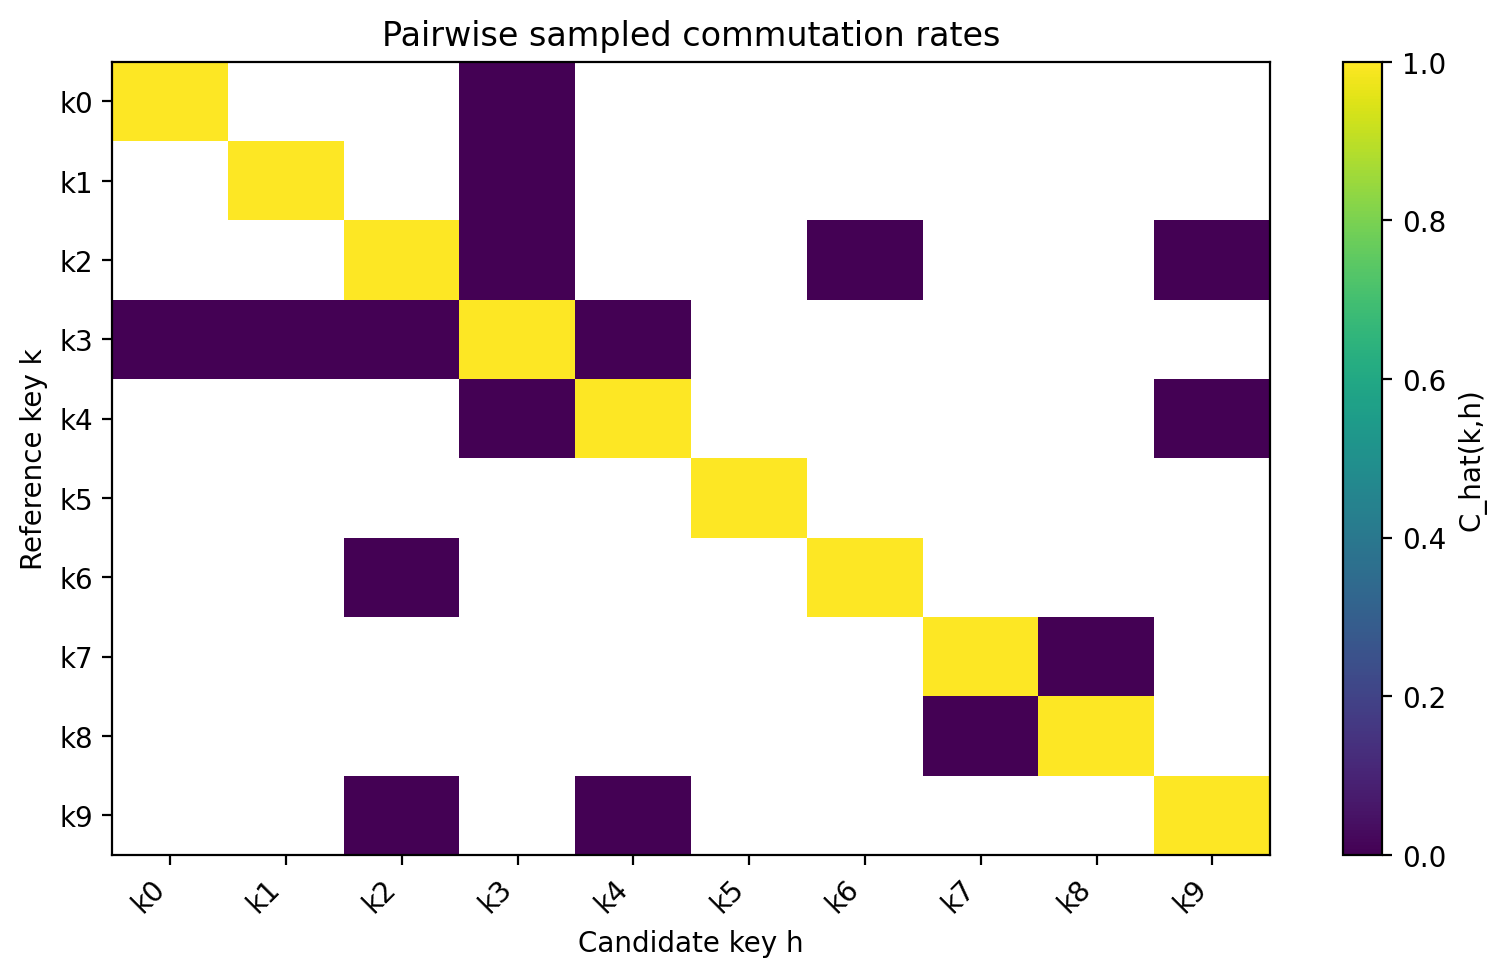

### exp5_commutation_rate_histogram.png

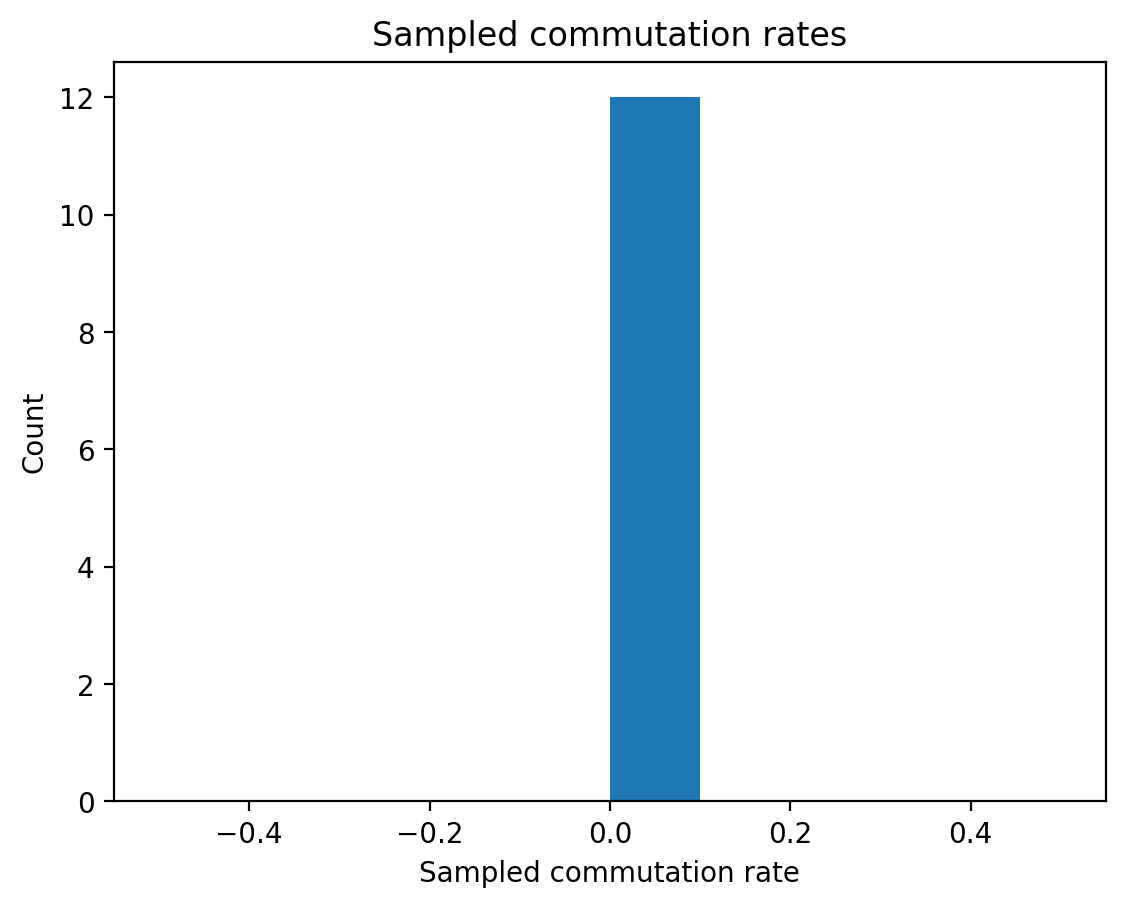

### exp6_decoded_edit_distance_by_perturbation.png

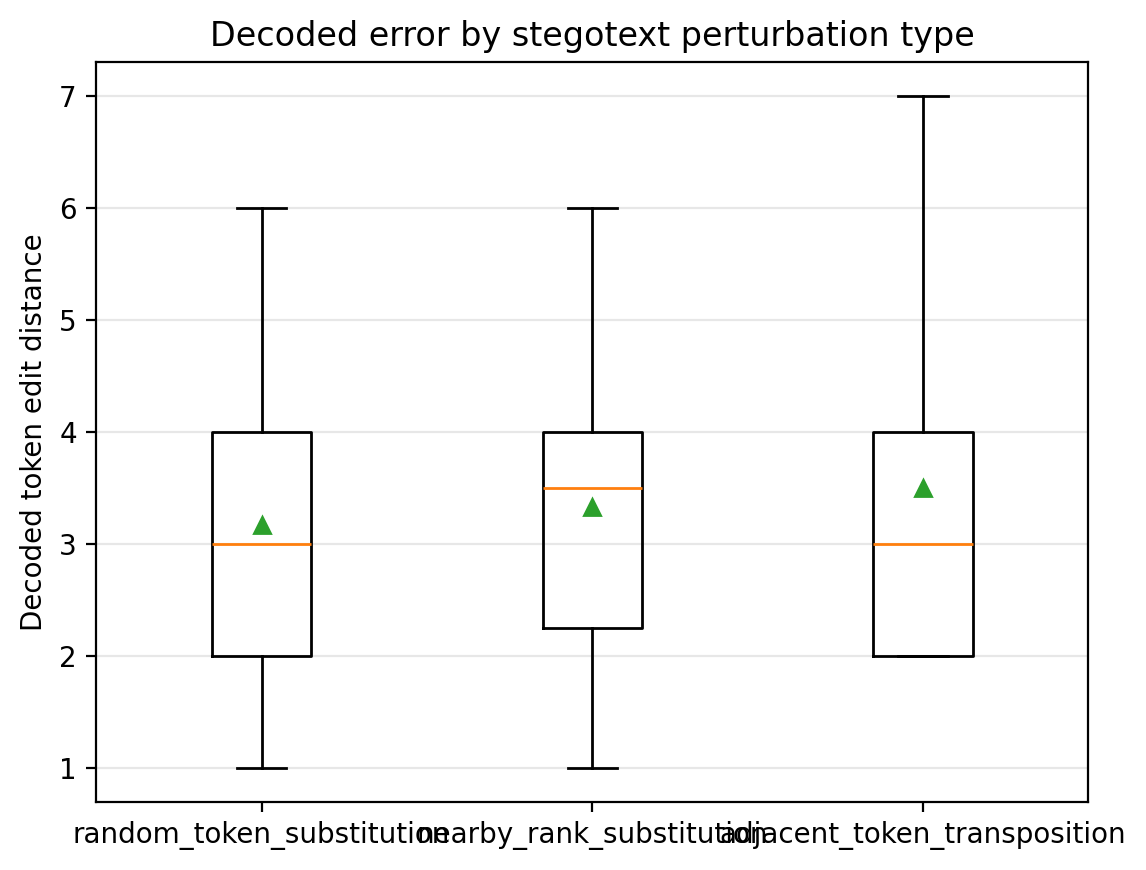

### exp6_perturb_position_vs_error_heatmap.png

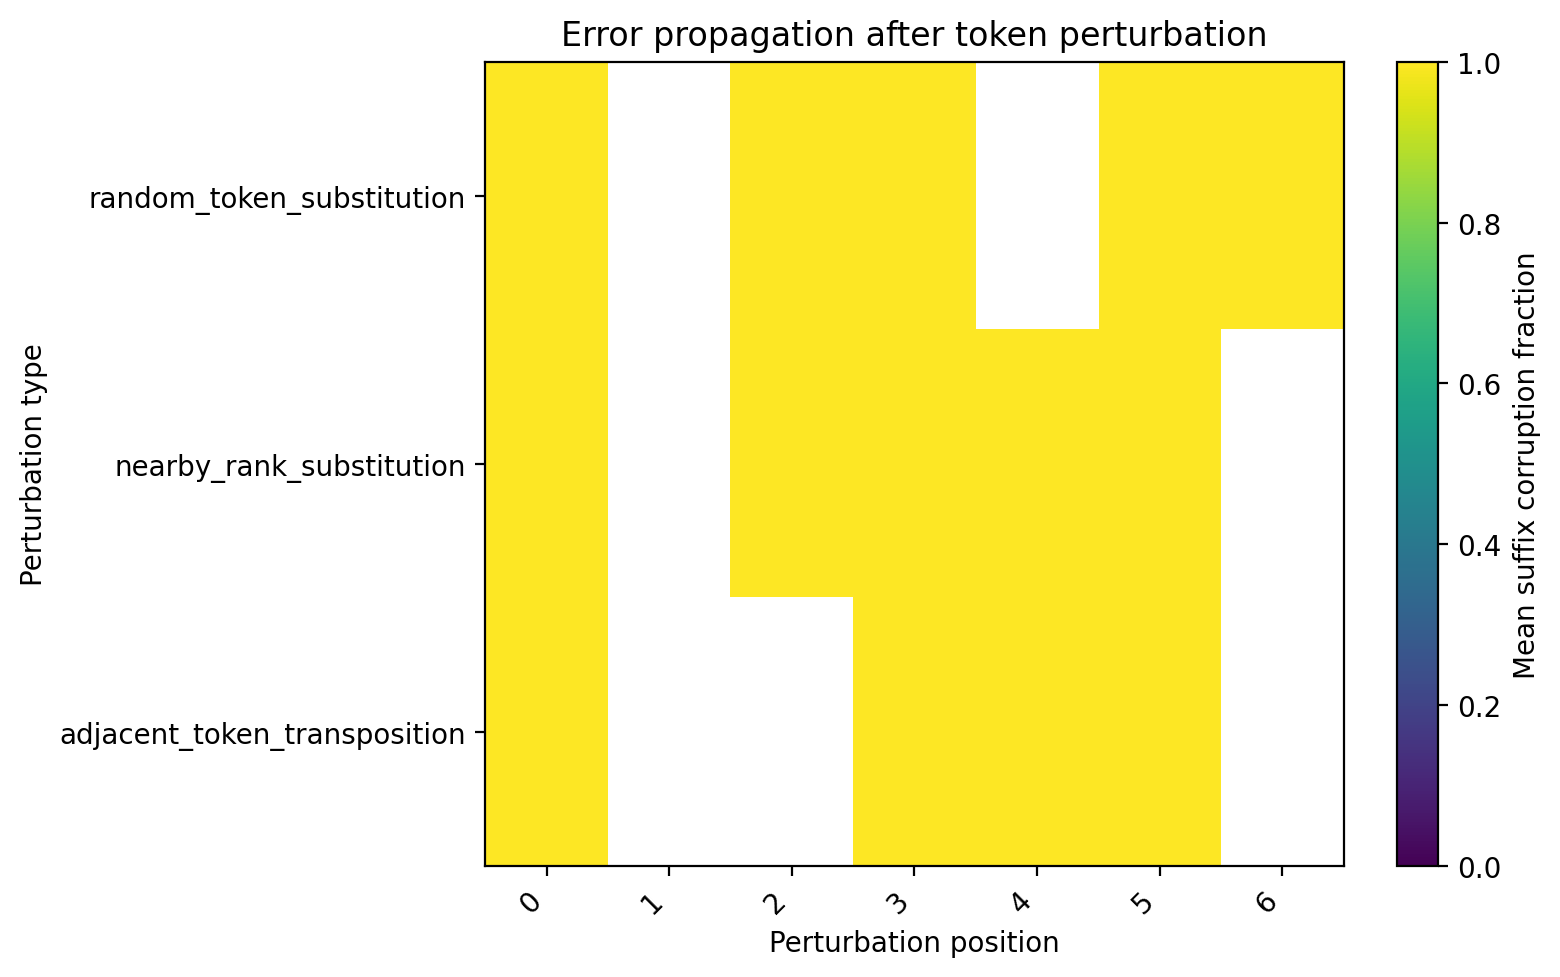

### exp6_token_agreement_after_perturbation.png

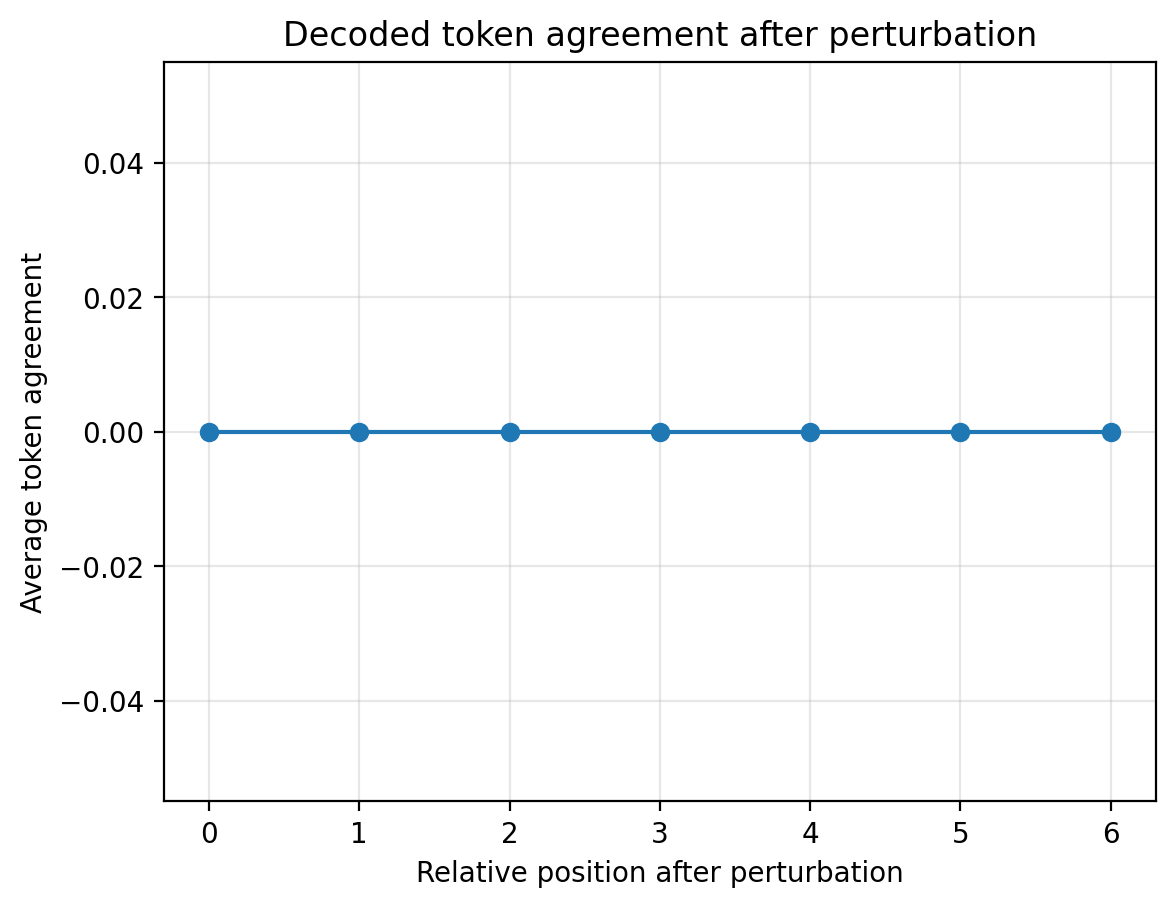

In [13]:
checklist_rows = [
    {"Theory claim": "Exact invertibility", "Experiment supporting it": "Experiment 1", "Figure/table produced": "experiment1_correctness.csv, exp1_correctness_bar.png", "Result summary": PAPER_BULLETS[0] if len(PAPER_BULLETS) > 0 else "not run", "Caveat": "Only verifies implementation samples; theorem is mathematical."},
    {"Theory claim": "Rank pressure and quality", "Experiment supporting it": "Experiment 2", "Figure/table produced": "exp2_nll_boxplot.png, exp2_mean_log_rank_cdf.png, exp2_tail_rank_vs_nll.png", "Result summary": PAPER_BULLETS[1] if len(PAPER_BULLETS) > 1 else "not run", "Caveat": "Depends on Q_k."},
    {"Theory claim": "Rank-trace detectability", "Experiment supporting it": "Experiment 2", "Figure/table produced": "exp2_detector_roc.png, exp2_positionwise_mean_log_rank_heatmap.png", "Result summary": PAPER_BULLETS[1] if len(PAPER_BULLETS) > 1 else "not run", "Caveat": "Not a full steganographic proof."},
    {"Theory claim": "Key-collision fibers", "Experiment supporting it": "Experiment 3", "Figure/table produced": "exp3_fiber_size_histogram.png, experiment3_largest_fibers.csv", "Result summary": PAPER_BULLETS[2] if len(PAPER_BULLETS) > 2 else "not run", "Caveat": "Finite K_adm only."},
    {"Theory claim": "Multi-transcript ambiguity", "Experiment supporting it": "Experiment 4", "Figure/table produced": "exp4_candidate_set_size_vs_transcripts.png", "Result summary": PAPER_BULLETS[3] if len(PAPER_BULLETS) > 3 else "not run", "Caveat": "Finite K_adm and sampled payloads."},
    {"Theory claim": "Non-commutativity", "Experiment supporting it": "Experiment 5", "Figure/table produced": "exp5_commutation_rate_histogram.png, exp5_commutation_heatmap.png", "Result summary": PAPER_BULLETS[4] if len(PAPER_BULLETS) > 4 else "not run", "Caveat": "No impossibility claim."},
    {"Theory claim": "Perturbation brittleness", "Experiment supporting it": "Experiment 6", "Figure/table produced": "exp6_decoded_edit_distance_by_perturbation.png, exp6_perturb_position_vs_error_heatmap.png", "Result summary": PAPER_BULLETS[5] if len(PAPER_BULLETS) > 5 else "not run", "Caveat": "Only tested listed perturbation types."},
]
cu.write_csv(cu.TABLES_DIR / "paper_verification_checklist.csv", checklist_rows)
record_table("paper_verification_checklist.csv", "Final checklist", "Theory-claim verification checklist for the paper.", "Maps empirical outputs to paper claims.")

cu.write_csv(cu.TABLES_DIR / "figure_manifest.csv", FIGURE_MANIFEST)
cu.write_csv(cu.TABLES_DIR / "table_manifest.csv", TABLE_MANIFEST)

figure_list_md = "\n".join(f"- `{row['figure_file']}`: {row['caption_suggestion']}" for row in FIGURE_MANIFEST)
table_list_md = "\n".join(f"- `{row['table_file']}`: {row['description']}" for row in TABLE_MANIFEST)
bullets_md = "\n".join(f"- {bullet}" for bullet in PAPER_BULLETS)

cu.append_summary("Figure manifest", figure_list_md or "No figures recorded.")
cu.append_summary("Table manifest", table_list_md or "No tables recorded.")
cu.append_summary("Limitations and caveats", "\n".join([
    "- Results are under this model and tokenizer, not all LLMs.",
    "- Finite key-search results are under this finite key set only.",
    "- The ordinary comparison distribution Q_k is greedy generation and is not a universal natural-text distribution.",
    "- Detector results do not prove steganographic security or insecurity.",
    "- Exact correctness assumes identical tokenization, logits, masking, precision, and tie-breaking.",
]))
cu.append_summary("Next steps", "\n".join([
    "- Increase sample sizes after confirming exact correctness.",
    "- Add stronger comparison distributions for Q_k.",
    "- Add calibrated plausibility metrics before wrong-key equivocation experiments.",
    "- Test another quantization or exact model variant only as a separately labeled run.",
]))
cu.append_summary("Paper-ready paragraphs", bullets_md or "No paper-ready bullets recorded.")

print("CSV files:")
for path in cu.list_saved_tables():
    print(" -", path)
print("Markdown summary:", cu.SUMMARY_PATH)
print("Paper-ready result bullets:")
for bullet in PAPER_BULLETS:
    print("-", bullet)

show_rows(checklist_rows, n=len(checklist_rows))

if Image is not None:
    for fig_path in cu.list_saved_figures():
        display(Markdown(f"### {fig_path.name}"))
        display(Image(filename=str(fig_path)))
